In [3]:
#load modules
import pandas as pd
import scanpy as sc
import numpy as np
import anndata
import os
from collections import Counter
from sklearn.decomposition import PCA
import anndata 
import matplotlib.pyplot as plt


In [2]:
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.logging.print_version_and_date()
# sc.settings.set_figure_params(dpi=100, color_map='RdBu_r')

Running Scanpy 1.11.3, on 2025-07-16 09:04.


In [2]:
no5_EC_adata_v0=sc.read_h5ad('/data2/core-med1/fibecker/nastaran/Xenotransplant/v2.0 results & data/data v2.0 (no5)/no5_EC_adata.h5ad')

In [4]:
# Check if 'cell_type_V1' exists in the obs columns
if 'cell_type_V1' in no5_EC_adata_v0.obs.columns:
    # Drop the column
    no5_EC_adata_v0.obs.drop(columns=['cell_type_V1'], inplace=True)
    print("'cell_type_V1' column has been deleted from the obs.")

# Save the updated dataset
no5_EC_adata = no5_EC_adata_v0.write('/data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/data v2.1/no5_EC_adata_cleaned.h5ad')

print("Updated dataset without 'cell_type_V1' column has been saved!")

'cell_type_V1' column has been deleted from the obs.
Updated dataset without 'cell_type_V1' column has been saved!


In [3]:
adata_initial=sc.read ('/data2/core-med1/fibecker/nastaran/Xenotransplant/v2.0 results & data/data v2.0 (no5)/no5_EC_adata.h5ad')

/opt/micromamba/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/micromamba/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/micromamba/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/micromamba/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a fut

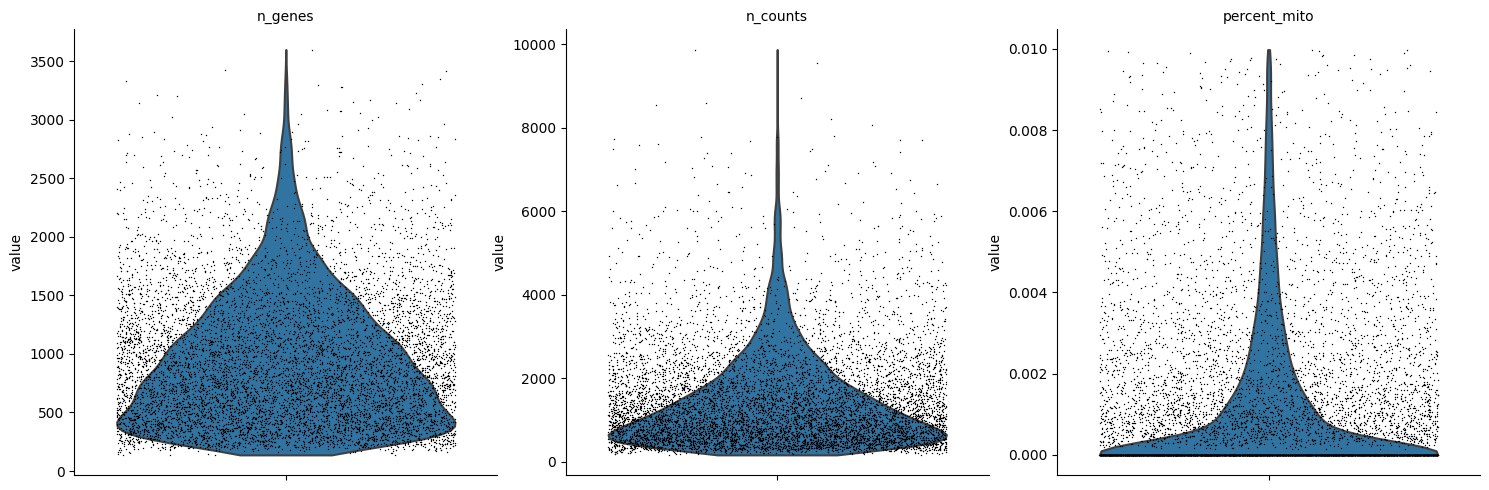

In [4]:
adata_initial.var["mt"] = adata_initial.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    adata_initial, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)

sc.pl.violin(
    adata_initial,
    ["n_genes", "n_counts", "percent_mito"],
    jitter=0.4,
    multi_panel=True)

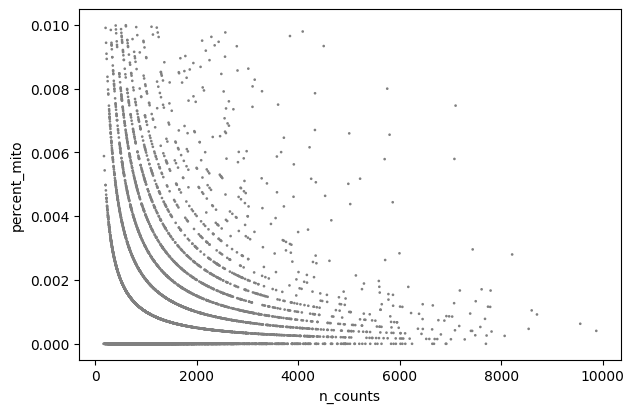

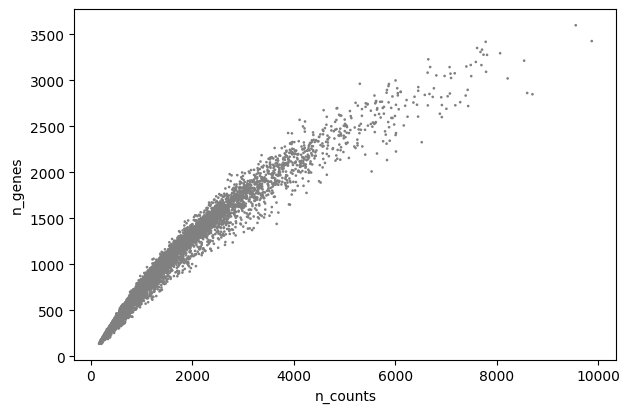

In [5]:
sc.pl.scatter(adata_initial, x="n_counts", y="percent_mito")
sc.pl.scatter(adata_initial, x="n_counts", y="n_genes")

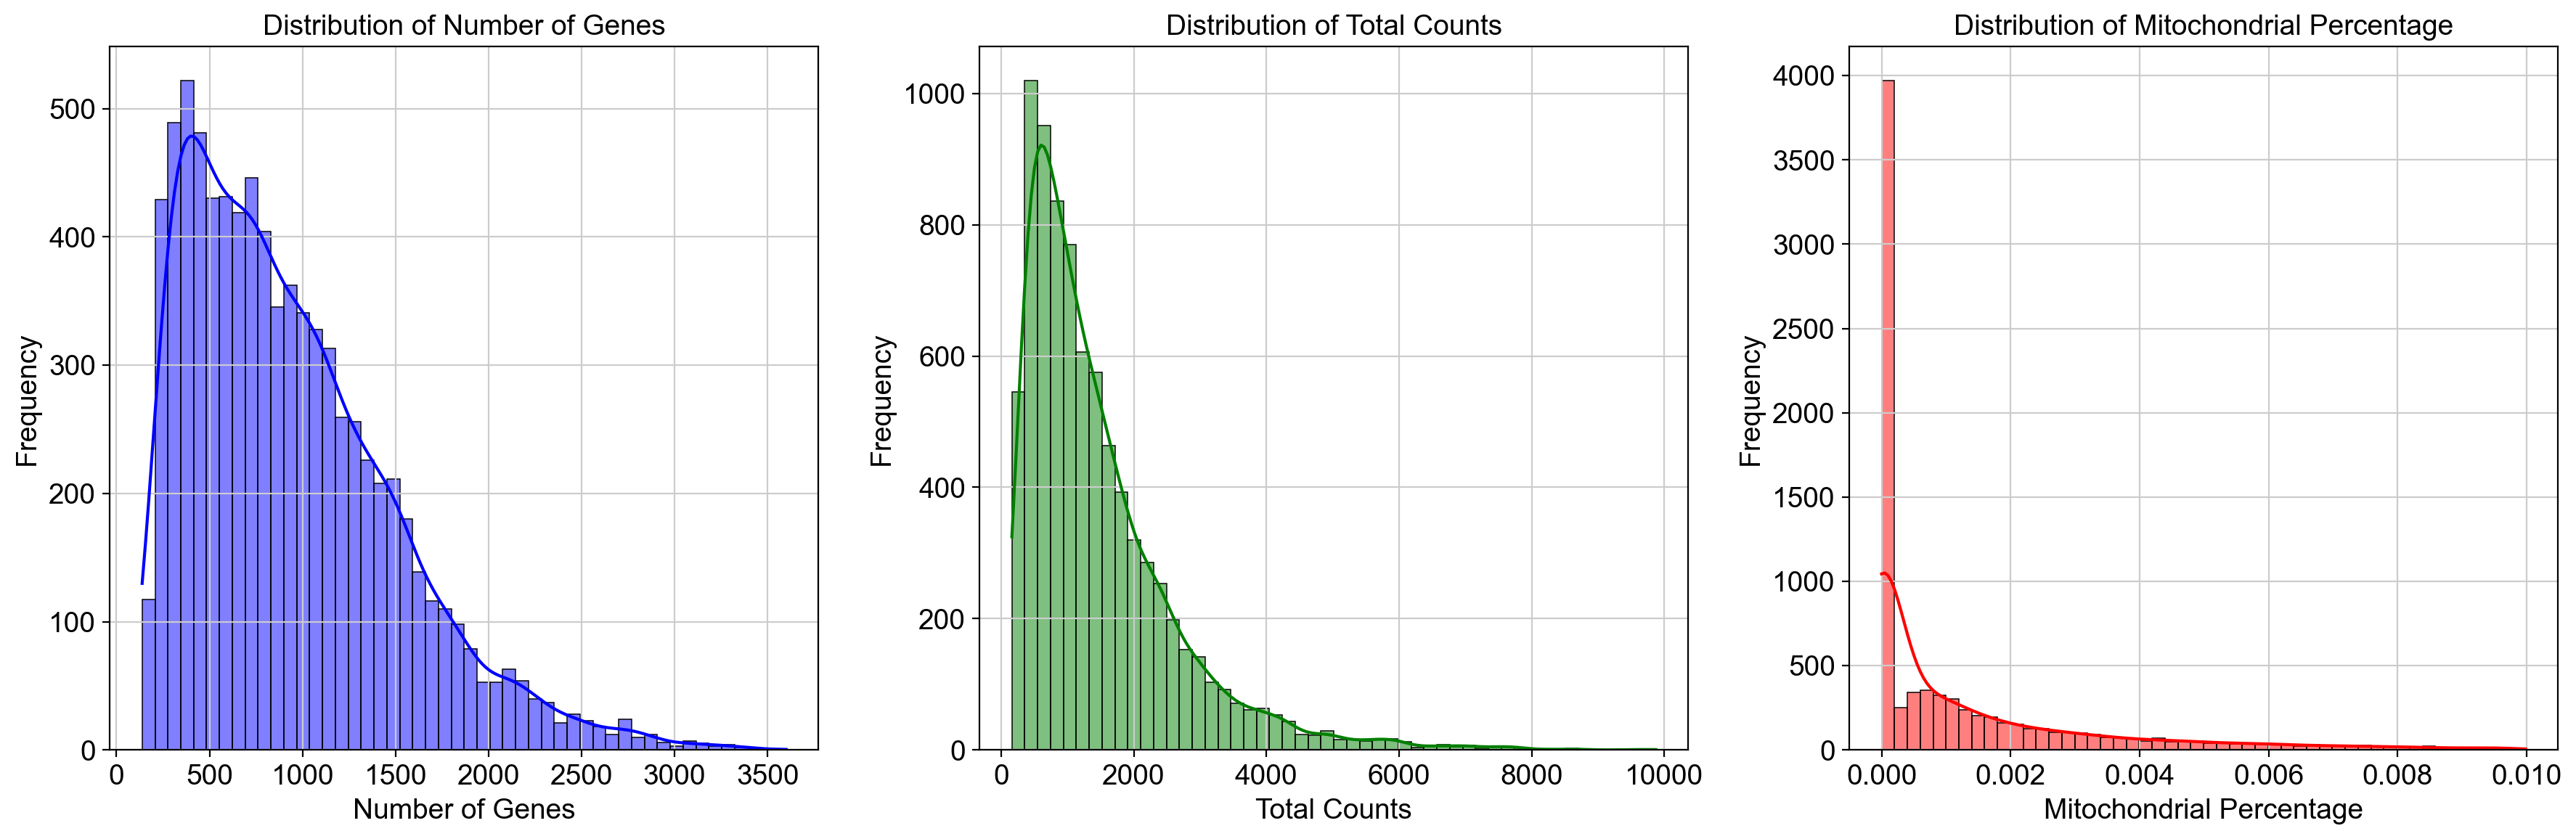

In [8]:
# 1. Visualize the distribution of key variables (n_genes, n_counts, percent_mito)
# Plot the distribution of n_genes, n_counts, and percent_mito

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.histplot(adata_initial.obs['n_genes'], kde=True, ax=axes[0], color='blue', bins=50)
axes[0].set_title('Distribution of Number of Genes')
axes[0].set_xlabel('Number of Genes')
axes[0].set_ylabel('Frequency')

sns.histplot(adata_initial.obs['n_counts'], kde=True, ax=axes[1], color='green', bins=50)
axes[1].set_title('Distribution of Total Counts')
axes[1].set_xlabel('Total Counts')
axes[1].set_ylabel('Frequency')

sns.histplot(adata_initial.obs['percent_mito'], kde=True, ax=axes[2], color='red', bins=50)
axes[2].set_title('Distribution of Mitochondrial Percentage')
axes[2].set_xlabel('Mitochondrial Percentage')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1598083/3589084917.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gene_expression_sums = adata_initial.obs.groupby(sample_column).apply(
/tmp/ipykernel_1598083/3589084917.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gene_expression_sums = adata_initial.obs.groupby(sample_column).apply(


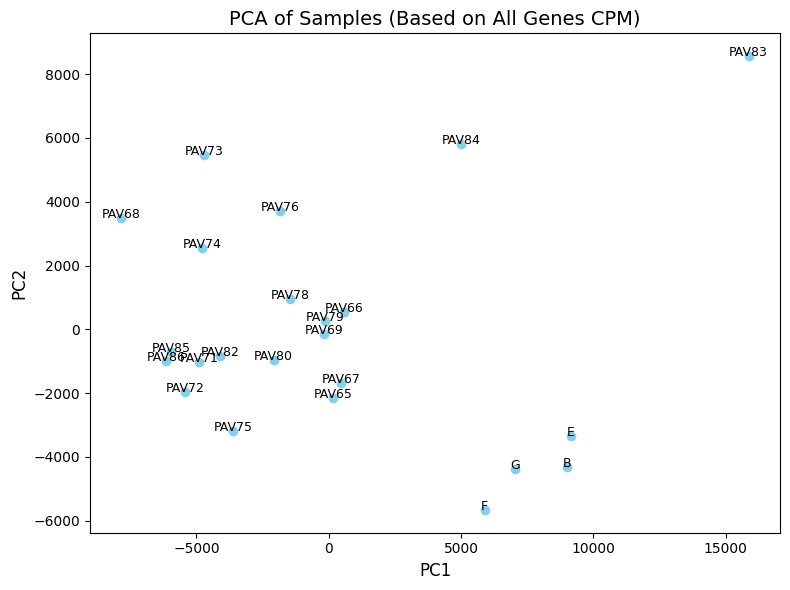

In [6]:
sample_column = 'Sample_ID'

if sample_column not in adata_initial.obs:
    raise ValueError(f"Column '{sample_column}' not found in final_EC_adata.obs")

gene_expression_sums = adata_initial.obs.groupby(sample_column).apply(
    lambda df: adata_initial[df.index, :].X.sum(axis=0)
)

gene_expression_sums = pd.DataFrame(
    data=np.vstack(gene_expression_sums.values),
    index=gene_expression_sums.index,
    columns=adata_initial.var_names
)

total_expression_per_sample = gene_expression_sums.sum(axis=1)
cpm_normalized = gene_expression_sums.div(total_expression_per_sample, axis=0) * 1e6

pca = PCA(n_components=2)
pca_results = pca.fit_transform(cpm_normalized)

pca_df = pd.DataFrame(
    data=pca_results,
    columns=['PC1', 'PC2'],
    index=gene_expression_sums.index
)

plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], color='skyblue')
for i, sample in enumerate(pca_df.index):
    plt.text(pca_df.iloc[i, 0], pca_df.iloc[i, 1], sample, fontsize=9, ha='center')
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.title('PCA of Samples (Based on All Genes CPM)', fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
sc.pp.normalize_total(no5_EC_adata, target_sum=1e4)

normalizing counts per cell
    finished (0:00:00)


In [11]:
sc.pp.log1p(no5_EC_adata)

In [12]:
# Store the full raw data for later use in DEA
no5_EC_adata.raw = no5_EC_adata.copy()  # Store raw data (all 53,826 genes)

In [13]:

# sc.pp.scale(no5_EC_adata, max_value=10)

# preprocessed_EC_adata = no5_EC_adata.write ('/data2/core-med1/fibecker/nastaran/Xenotransplant/v2.0 results & data/data v2.0 (no5)/preprocessed_noHVG_EC_adata_no5.h5ad')

... as `zero_center=True`, sparse input is densified and may lead to large memory consumption


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [21]:

# preprocessed_EC_adata = sc.read ('/data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/data v2.1/preprocessed_noHVG_EC_adata_no5.h5ad')

extracting highly variable genes


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


    finished (0:00:02)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


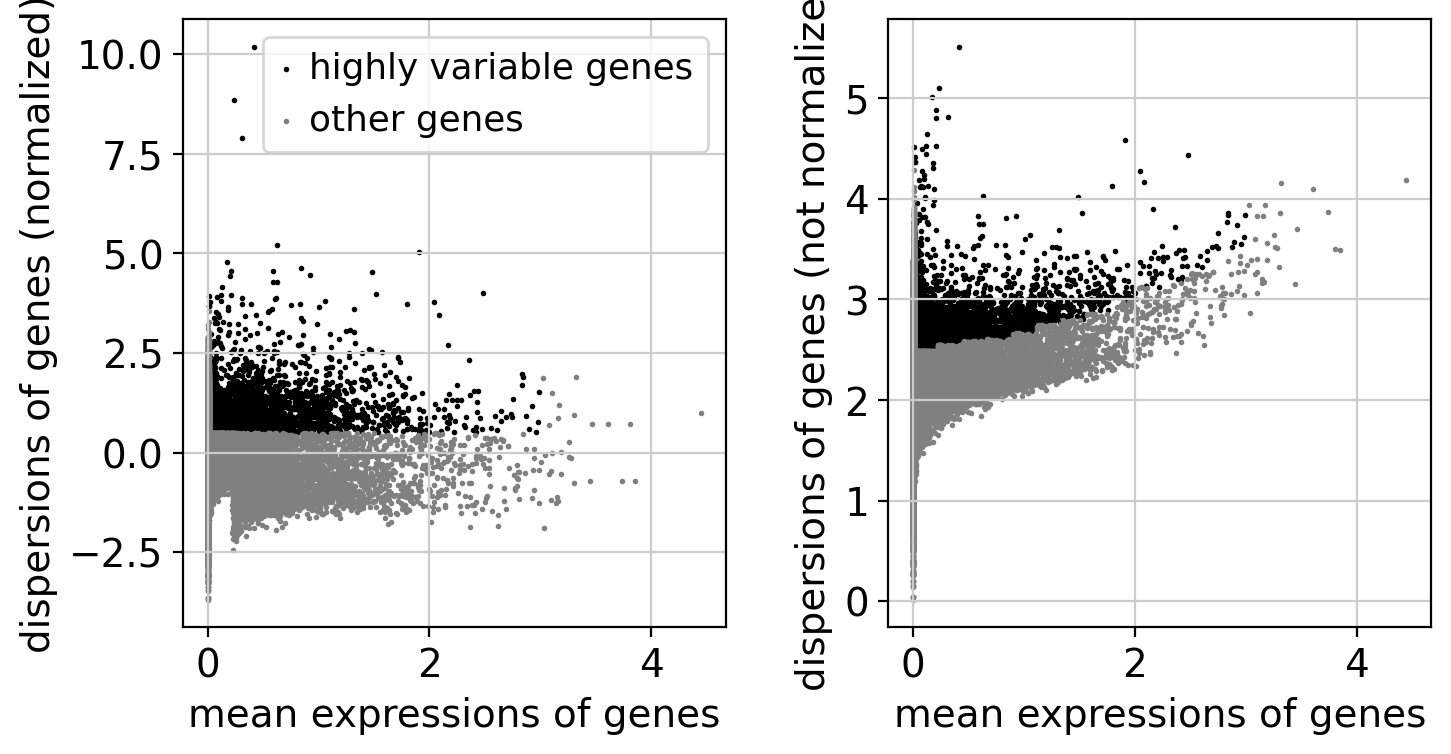

In [15]:
high_genes = sc.pp.highly_variable_genes(no5_EC_adata, min_mean=0.01, max_mean=3, min_disp=0.5)
sc.pl.highly_variable_genes(no5_EC_adata)

In [16]:
sc.pp.scale(no5_EC_adata, max_value=10)

... as `zero_center=True`, sparse input is densified and may lead to large memory consumption


In [19]:
# Subset the data to HVGs for dimensionality reduction and clustering
EC_adata_hvg = no5_EC_adata[:, no5_EC_adata.var.highly_variable]

# Save the HVG-only dataset for reproducibility
EC_adata_hvg = EC_adata_hvg.write('/data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/data v2.1/hvg_EC_adata_no5.h5ad')

In [3]:
EC_adata_hvg = sc.read('/data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/data v2.1/hvg_EC_adata_no5.h5ad')

In [22]:
# Check the number of highly variable genes
num_highly_variable_genes = EC_adata_hvg.var['highly_variable'].sum()
print(f'Number of highly variable genes: {num_highly_variable_genes}')

Number of highly variable genes: 4855


computing PCA
    with n_comps=50
    finished (0:00:11)


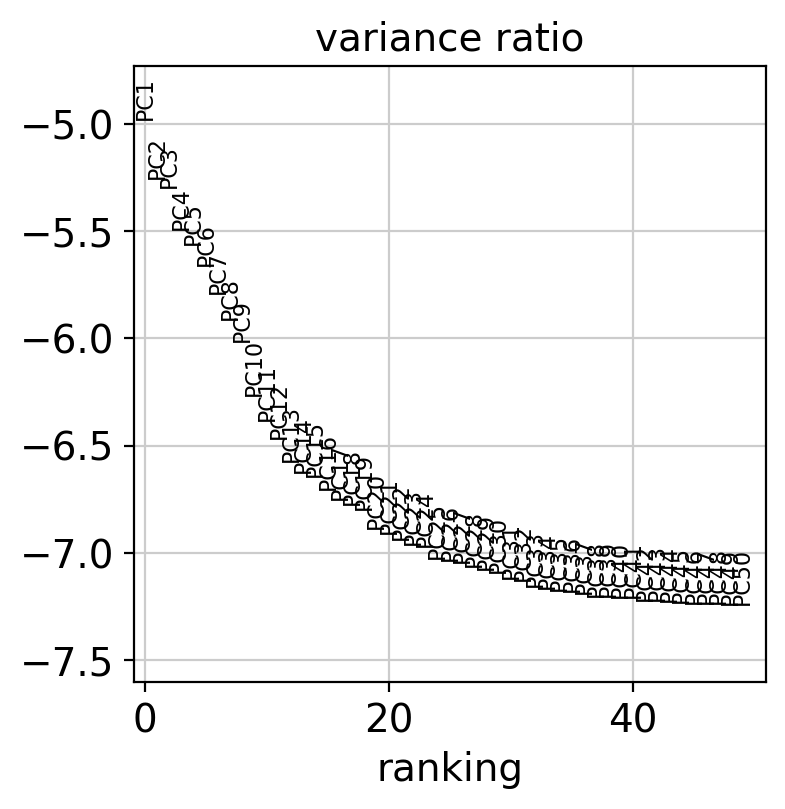

<Figure size 400x400 with 0 Axes>

In [23]:
# Perform PCA
sc.tl.pca(EC_adata_hvg, svd_solver='arpack')

# Plot the explained variance to decide how many PCs to use
sc.pl.pca_variance_ratio(EC_adata_hvg, log=True, n_pcs=50)
plt.savefig('/data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/data v2.1/EC_hvg_PCA.png')
plt.show()

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:19)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:11)


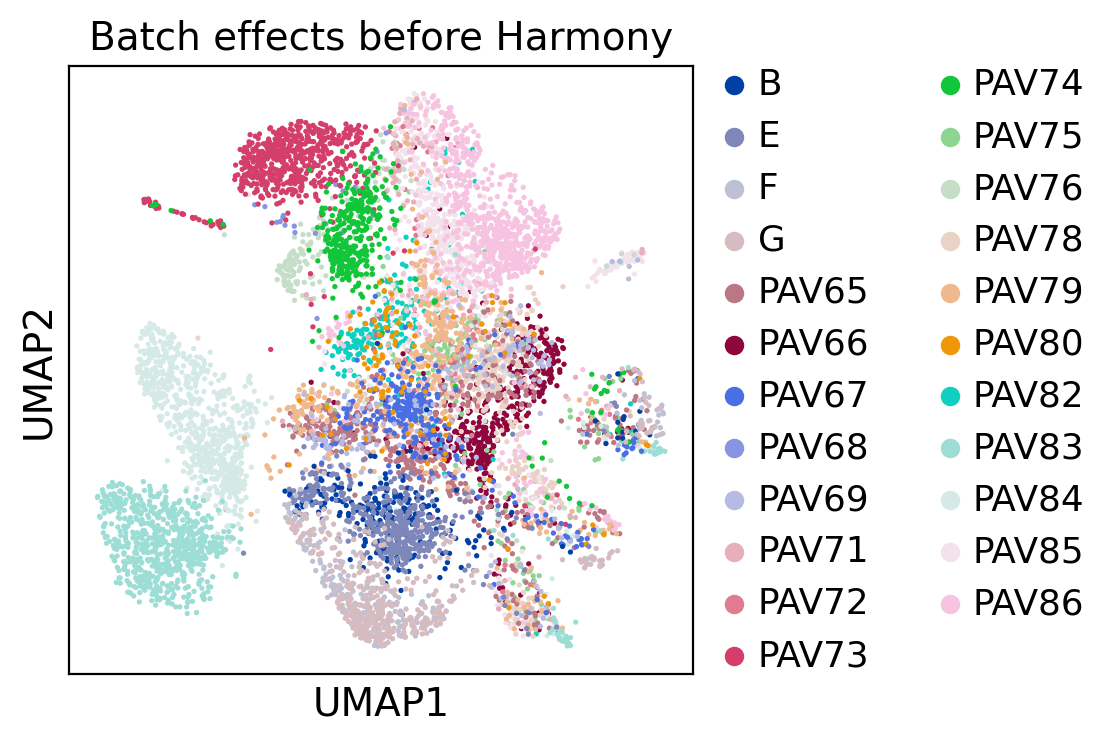

In [24]:
# Checking batch effects before Harmony
sc.pp.neighbors(EC_adata_hvg, random_state=10, n_neighbors=25, n_pcs=50)

# Perform UMAP
sc.tl.umap(EC_adata_hvg)

# Plot UMAP colored by sample (batch) and save it
sc.pl.umap(
    EC_adata_hvg, 
    color=['Sample_ID'], 
    title='Batch effects before Harmony'
)

In [25]:
# Extract PCA embeddings and metadata
pca = EC_adata_hvg.obsm['X_pca'][:, :50]  # Use the first 40 principal components
meta_data = EC_adata_hvg.obs  # Metadata, including Sample_IDs

# Run Harmony batch correction
ho = hm.run_harmony(
    pca, 
    meta_data, 
    ['Sample_ID'],  # Correct for batch effects based on 'Sample_ID'
    epsilon_harmony=-float('Inf'), 
    epsilon_cluster=-float('Inf'), 
    random_state=10
)

2025-01-07 11:31:10,450 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-01-07 11:31:13,893 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-01-07 11:31:13,999 - harmonypy - INFO - Iteration 1 of 10
2025-01-07 11:31:15,868 - harmonypy - INFO - Iteration 2 of 10
2025-01-07 11:31:17,655 - harmonypy - INFO - Iteration 3 of 10
2025-01-07 11:31:19,432 - harmonypy - INFO - Iteration 4 of 10
2025-01-07 11:31:21,225 - harmonypy - INFO - Iteration 5 of 10
2025-01-07 11:31:23,015 - harmonypy - INFO - Iteration 6 of 10
2025-01-07 11:31:24,805 - harmonypy - INFO - Iteration 7 of 10
2025-01-07 11:31:26,581 - harmonypy - INFO - Iteration 8 of 10
2025-01-07 11:31:28,367 - harmonypy - INFO - Iteration 9 of 10
2025-01-07 11:31:30,150 - harmonypy - INFO - Iteration 10 of 10
2025-01-07 11:31:31,938 - harmonypy - INFO - Stopped before convergence


In [26]:
# Alternative way to implement embeddings after harmony
res=pd.DataFrame(ho.Z_corr)
res=res.T
EC_adata_hvg.obsm['X_pca']=res.values

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:11)


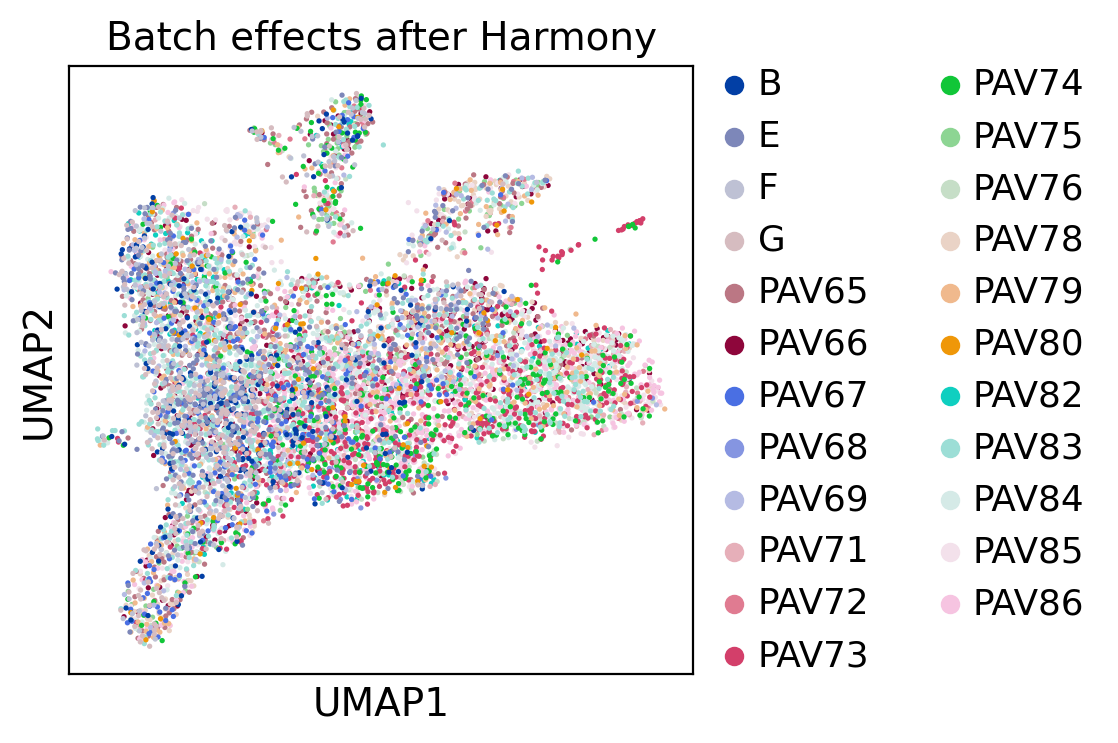

In [30]:
# Compute neighbors using harmonized_EC_adata-corrected embeddings
sc.pp.neighbors(EC_adata_hvg, random_state=10, n_neighbors=25, n_pcs=50, use_rep='X_pca')

# Perform UMAP
sc.tl.umap(EC_adata_hvg)

# Plot UMAP colored by sample (batch)
sc.pl.umap(EC_adata_hvg, color=['Sample_ID'], title='Batch effects after Harmony')

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:11)
running Leiden clustering
    finished: found 12 clusters and added
    'subtype_leiden', the cluster labels (adata.obs, categorical) (0:00:04)


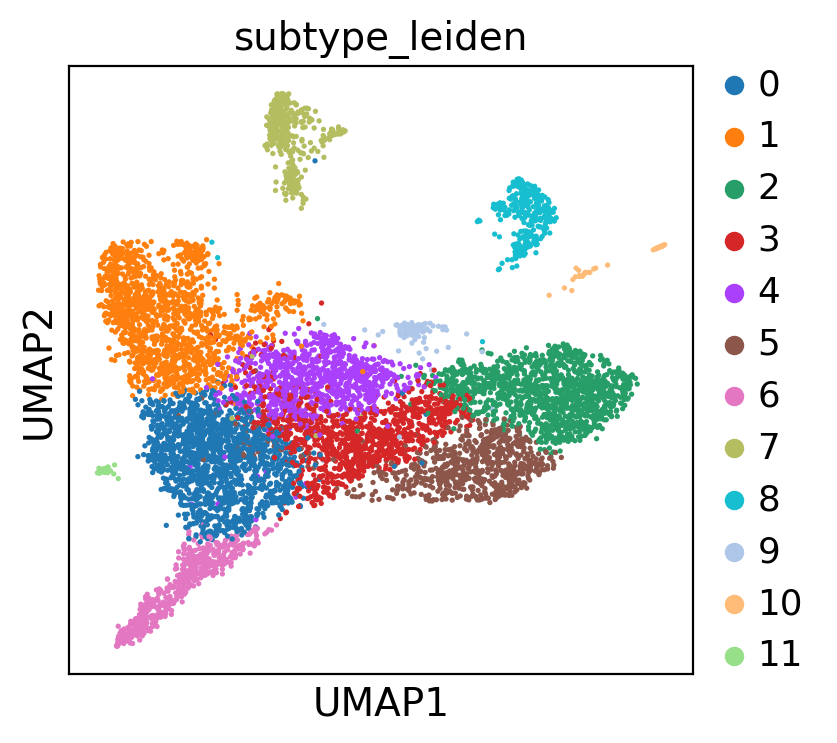

In [40]:
# Step 1: Compute the nearest neighbors on HVG-subsetted data
sc.pp.neighbors(EC_adata_hvg, n_neighbors=25, n_pcs=50, random_state=10)

# Step 2: Perform UMAP on HVG-subsetted data
sc.tl.umap(
    EC_adata_hvg,
    random_state=10,
    min_dist=0.2,
    spread=1
)

# Step 3: Perform Leiden clustering on HVG-subsetted data
sc.tl.leiden(
    EC_adata_hvg,
    resolution=0.9,
    random_state=10,
    key_added="subtype_leiden"
)

# Step 4: Plot UMAP using the original data but with the clustering results
sc.pl.umap(EC_adata_hvg, color=["subtype_leiden"])

In [41]:
sc.settings.verbosity = 2

In [31]:
def stacked_barplot(adata, xaxis, stack, xaxis_label, legend_label, shift_top=0.2, xaxis_rotation=45, figsize=(10,10), percent=True):
    tmp=pd.crosstab(adata.obs[xaxis],
                adata.obs[stack]).sum(axis=1)
    
    ax= pd.crosstab(adata.obs[xaxis], 
                    adata.obs[stack]).apply(lambda r: r/r.sum()*100, axis=1)
    #ax_1 = ax.plot.bar(figsize=(10,10),stacked=True, rot=0, colors=colors)
    ax_1 = ax.plot.bar(figsize=figsize,stacked=True, rot=0)
    #display(ax)
    #plt.legend(title="Subject") # loc='upper center', bbox_to_anchor=(0.1, 1.0), 
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title=legend_label)
    plt.xlabel(xaxis_label,fontweight="bold")
    plt.ylabel('Percent Distribution',fontweight="bold")
    
    if percent:
        for rec in ax_1.patches:
            height = rec.get_height()
            ax_1.text(rec.get_x() + rec.get_width() / 2, rec.get_y() + height/2, "{:.0f}%".format(height),
                   ha = 'center', va='center', fontsize=14.5, weight='bold') #
    
    for xaxistick in range(ax.shape[0]):
        ax_1.text(xaxistick-shift_top,110,tmp[xaxistick],va='center', rotation=45, fontsize=14.5, weight='bold')
    
    plt.xticks(rotation=xaxis_rotation)
    
    ax_1.grid(False)
    plt.show()

In [32]:
def filter_by_expression(adata_obj, DE_column, key='wilcoxon'):
#adata_obj=fbs_new_harmony.copy()
#key='rank_genes_groups'
#DE_column='leiden'
    def to_tensor(dataframe, columns = [], dtypes = {}, index = False):
        to_records_kwargs = {'index': index}
        if not columns:  # Default to all `dataframe.columns`
            columns = dataframe.columns
        if dtypes:       # Pull in modifications only for dtypes listed in `columns`
            to_records_kwargs['column_dtypes'] = {}
            for column in dtypes.keys():
                if column in columns:
                    to_records_kwargs['column_dtypes'].update({column: dtypes.get(column)})
        return dataframe[columns].to_records(**to_records_kwargs)
    gene_names = pd.DataFrame(adata_obj.uns[key]['names'])
    fraction_in_cluster_matrix = pd.DataFrame(
                np.zeros(gene_names.shape),
                columns=gene_names.columns,
                index=gene_names.index,
            )
    fraction_notin_cluster_matrix = pd.DataFrame(
                np.zeros(gene_names.shape),
                columns=gene_names.columns,
                index=gene_names.index,
            )
    in_cluster_expr_matrix = pd.DataFrame(
                np.zeros(gene_names.shape),
                columns=gene_names.columns,
                index=gene_names.index,
            )
    notin_cluster_matrix = pd.DataFrame(
                np.zeros(gene_names.shape),
                columns=gene_names.columns,
                index=gene_names.index,
            )
    allin_cluster_expr_matrix = pd.DataFrame(
                np.zeros(gene_names.shape),
                columns=gene_names.columns,
                index=gene_names.index,
            )
    allnotin_cluster_matrix = pd.DataFrame(
                np.zeros(gene_names.shape),
                columns=gene_names.columns,
                index=gene_names.index,
            )
    # Create a Adata raw with raw in .X -> We might remove this step - redundant!
    dummy=anndata.AnnData(X=adata_obj.raw.X,
                   var=adata_obj.raw.var,
                   obs=adata_obj.obs)
    # We split the adata by Cell-type. Genes are ordered according to ranks from DEgene analysis
    dummy_split=[dummy[dummy.obs[DE_column].isin([i]),
                  gene_names[i]] for i in gene_names.columns]
    dummy_split_adatasize=[i.shape[0] for i in dummy_split] # How many cells we have in-cluster
    dummy_outcluster=[dummy[~dummy.obs[DE_column].isin([i]),
                       gene_names[i]] for i in gene_names.columns]
    dummy_split_adatasize_outcluster=[i.shape[0] for i in dummy_outcluster] # How many cells we have in out-cluster
    for adata, sizeof_adata, adata_outcluster, sizeof_adata_outcluster in zip(dummy_split, dummy_split_adatasize, 
                                                     dummy_outcluster, dummy_split_adatasize_outcluster):
        cluster_number=[(adata.obs[DE_column].unique()).tolist()][0]
        #incluster_rows, incluster_cols=adata.X.nonzero()
        #https://stackoverflow.com/questions/3797158/counting-non-zero-elements-within-each-row-and-within-each-column-of-a-2d-numpy
        #incluster_counts = [len(np.where(incluster_cols==i)[0]) for i in range(0,adata.shape[1])]
        incluster_counts=np.diff(adata.X.tocsc().indptr)
        percent_expression_incluster=np.array(incluster_counts)/sizeof_adata 
        fraction_in_cluster_matrix[cluster_number[0]]=percent_expression_incluster
        #outcluster_rows, outcluster_cols=adata_outcluster.X.nonzero()
        #outcluster_counts = [len(np.where(outcluster_cols==i)[0]) for i in range(0,adata_outcluster.shape[1])]
        outcluster_counts=np.diff(adata_outcluster.X.tocsc().indptr)
        percent_expression_outcluster=np.array(outcluster_counts)/sizeof_adata_outcluster 
        fraction_notin_cluster_matrix[cluster_number[0]]=percent_expression_outcluster
        # Expression_all in cluster
        allin_cluster_expr_matrix[cluster_number[0]]=np.squeeze(np.asarray(adata.X.mean(axis=0)))
        allnotin_cluster_matrix[cluster_number[0]]=np.squeeze(np.asarray(adata_outcluster.X.mean(axis=0)))
    # Generate the last table results
    result = adata_obj.uns['wilcoxon']
    groups = result['names'].dtype.names
    result['pi'] = to_tensor(fraction_in_cluster_matrix)
    result['po'] = to_tensor(fraction_notin_cluster_matrix)
    result['ei'] = to_tensor(allin_cluster_expr_matrix)
    result['eo'] = to_tensor(allnotin_cluster_matrix)
    results =pd.DataFrame(
        {group + '_' + key[:2]: result[key][group]
        for group in groups for key in ['names', 'pvals_adj', 'logfoldchanges', 'pi', 'po', "ei", "eo"]})
    return results

In [2]:
# Perform differential expression to find marker genes for each cluster using Wilcoxon test on raw data
sc.tl.rank_genes_groups(EC_adata_hvg, 'subtype_leiden', method='wilcoxon', key_added='wilcoxon', use_raw=True)

# Visualize the top marker genes for each cluster
sc.pl.rank_genes_groups(EC_adata_hvg, key='wilcoxon', n_genes=30, sharey=False)

# Save the DE analysis to an H5AD file
dea_adata = EC_adata_hvg.write('/data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/data v2.1/DEA_adata.h5ad')

In [1]:
# Load the DEA adata
dea_adata = sc.read('/data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/data v2.1/DEA_adata.h5ad')

In [19]:
import os
# Define the output directory
output_dir = '/data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/results v2.1/Complete DEG results/'
os.makedirs(output_dir, exist_ok=True)  # Ensure the output directory exists

# Access the DE results stored in dea_adata.uns['wilcoxon']
de_results = dea_adata.uns['wilcoxon']

# Extract log-fold changes, p-values, and adjusted p-values
logfoldchanges = de_results['logfoldchanges']
pvals = de_results['pvals']
pvals_adj = de_results['pvals_adj']

# Loop through each cluster and save DEGs to a separate CSV file
for cluster in dea_adata.obs['subtype_leiden'].cat.categories:
    # Extract the top genes for the current cluster
    gene_names = de_results['names'][cluster]
    logfc = logfoldchanges[cluster]
    pval = pvals[cluster]
    adj_pval = pvals_adj[cluster]
    
    # Create a DataFrame for the cluster's DEGs
    degs_df = pd.DataFrame({
        'Gene': gene_names,
        'LogFoldChange': logfc,
        'PValue': pval,
        'AdjustedPValue': adj_pval
    })
    
    # Save the DataFrame to a CSV file
    output_file = os.path.join(output_dir, f"DEGs_cluster_{cluster}.csv")
    degs_df.to_csv(output_file, index=False)
    print(f"Saved DEGs for cluster {cluster} to {output_file}")


Saved DEGs for cluster 0 to /data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/results v2.1/Complete DEG results/DEGs_cluster_0.csv
Saved DEGs for cluster 1 to /data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/results v2.1/Complete DEG results/DEGs_cluster_1.csv
Saved DEGs for cluster 2 to /data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/results v2.1/Complete DEG results/DEGs_cluster_2.csv
Saved DEGs for cluster 3 to /data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/results v2.1/Complete DEG results/DEGs_cluster_3.csv
Saved DEGs for cluster 4 to /data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/results v2.1/Complete DEG results/DEGs_cluster_4.csv
Saved DEGs for cluster 5 to /data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/results v2.1/Complete DEG results/DEGs_cluster_5.csv
Saved DEGs for cluster 6 to /data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & d

In [20]:
# Filter the top genes criteria by log fold and pvals

output_dir = '/data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/results v2.1/Filtered DEG results 0.5 and 0.05/'
os.makedirs(output_dir, exist_ok=True)  # Ensure the output directory exists

# Access the DE results stored in dea_adata.uns['wilcoxon']
de_results = dea_adata.uns['wilcoxon']

# Extract log-fold changes, p-values, and adjusted p-values
logfoldchanges = de_results['logfoldchanges']
pvals = de_results['pvals']
pvals_adj = de_results['pvals_adj']

# Loop through each cluster and save filtered DEGs to a separate CSV file
for cluster in dea_adata.obs['subtype_leiden'].cat.categories:
    # Extract the DE data for the current cluster
    gene_names = de_results['names'][cluster]
    logfc = logfoldchanges[cluster]
    pval = pvals[cluster]
    adj_pval = pvals_adj[cluster]
    
    # Create a DataFrame for the cluster's DEGs
    degs_df = pd.DataFrame({
        'Gene': gene_names,
        'LogFoldChange': logfc,
        'PValue': pval,
        'AdjustedPValue': adj_pval
    })
    
    # Filter the DataFrame based on the criteria
    filtered_degs_df = degs_df[
        (degs_df['LogFoldChange'] > 1.4) & (degs_df['PValue'] < 0.05)
    ]
    
    # Save the filtered DataFrame to a CSV file if it contains data
    if not filtered_degs_df.empty:
        output_file = os.path.join(output_dir, f"Filtered_DEGs_cluster_{cluster}.csv")
        filtered_degs_df.to_csv(output_file, index=False)
        print(f"Saved filtered DEGs for cluster {cluster} to {output_file}")
    else:
        print(f"No DEGs meeting criteria for cluster {cluster}")

Saved filtered DEGs for cluster 0 to /data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/results v2.1/Filtered DEG results 0.5 and 0.05/Filtered_DEGs_cluster_0.csv
Saved filtered DEGs for cluster 1 to /data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/results v2.1/Filtered DEG results 0.5 and 0.05/Filtered_DEGs_cluster_1.csv
Saved filtered DEGs for cluster 2 to /data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/results v2.1/Filtered DEG results 0.5 and 0.05/Filtered_DEGs_cluster_2.csv
Saved filtered DEGs for cluster 3 to /data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/results v2.1/Filtered DEG results 0.5 and 0.05/Filtered_DEGs_cluster_3.csv
Saved filtered DEGs for cluster 4 to /data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/results v2.1/Filtered DEG results 0.5 and 0.05/Filtered_DEGs_cluster_4.csv
Saved filtered DEGs for cluster 5 to /data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.

In [4]:
# # Label transferring
# dea_adata = sc.read('/data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/data v2.1/DEA_adata.h5ad')
# preprocessed_EC_adata = sc.read('/data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/data v2.1/preprocessed_noHVG_EC_adata_no5.h5ad')

# # Ensure both datasets have matching cells based on their obs_names (cell identifiers)
# dea_adata = dea_adata[preprocessed_EC_adata.obs_names].copy()  # Align the cells in both objects

# # Transfer attributes from dea_adata to preprocessed_EC_adata

# # 1. Transfer 'subtype_leiden' clustering labels
# preprocessed_EC_adata.obs['subtype_leiden'] = dea_adata.obs['subtype_leiden'].values

# # 2. Transfer PCA embeddings
# if 'X_pca' in dea_adata.obsm:
#     preprocessed_EC_adata.obsm['X_pca'] = dea_adata.obsm['X_pca']

# # 3. Transfer UMAP embeddings
# if 'X_umap' in dea_adata.obsm:
#     preprocessed_EC_adata.obsm['X_umap'] = dea_adata.obsm['X_umap']

# # 4. Transfer 'uns' entries
# keys_to_transfer = ['hvg', 'neighbors', 'pca', 'subtype_leiden', 'subtype_leiden_colors', 'umap', 'wilcoxon']
# for key in keys_to_transfer:
#     if key in dea_adata.uns:
#         preprocessed_EC_adata.uns[key] = dea_adata.uns[key]

# # Verify the transfer
# print("Transferred 'subtype_leiden':")
# print(preprocessed_EC_adata.obs['subtype_leiden'].head())

# if 'X_pca' in preprocessed_EC_adata.obsm:
#     print("PCA shape:", preprocessed_EC_adata.obsm['X_pca'].shape)

# if 'X_umap' in preprocessed_EC_adata.obsm:
#     print("UMAP shape:", preprocessed_EC_adata.obsm['X_umap'].shape)

# # Save the updated preprocessed_EC_adata
# output_path = '/data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/data v2.1/label_transferred_preprocessed_EC_adata.h5ad'
# preprocessed_EC_adata.write(output_path)
# print(f"Updated preprocessed_EC_adata saved to {output_path}")

In [20]:


preprocessed_EC_adata = sc.read('/data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/data v2.1/label_transferred_preprocessed_EC_adata.h5ad')

In [21]:
# This filtering step excludes genes with very low or very high expression from the correlation analysis.

def correlation_analysis_with_raw(scanpy_object, column_to_split_by, aggregation):
    """
    Computes a summary statistic (mean or sum) for each gene across clusters 
    using the raw data matrix and returns the Pearson correlation matrix.

    Parameters:
        scanpy_object: AnnData
            The annotated data object containing the snRNA-seq data.
        column_to_split_by: str
            The column in `scanpy_object.obs` to group by (e.g., cluster labels).
        aggregation: str
            "mean" or "sum" to specify how to summarize gene expression in each cluster.

    Returns:
        pd.DataFrame:
            A DataFrame representing the Pearson correlation matrix.
    """
    if scanpy_object.raw is None:
        raise ValueError("Raw data is not available in the provided AnnData object.")
    
    summary_dict = {}

    for cluster in np.unique(scanpy_object.obs[column_to_split_by].values):
        # Subset the data for the current cluster
        cluster_subset = scanpy_object[scanpy_object.obs[column_to_split_by] == cluster]

        # Use the raw data matrix
        data_matrix = cluster_subset.raw.X

        # Compute the aggregation for each gene
        if aggregation == "mean":
            summary_dict[cluster] = np.squeeze(np.asarray(data_matrix.mean(axis=0)))
        elif aggregation == "sum":
            summary_dict[cluster] = np.squeeze(np.asarray(data_matrix.sum(axis=0)))

        del cluster_subset

    # Convert the summary dictionary to a DataFrame
    summary_df = pd.DataFrame.from_dict(summary_dict, orient='index').T
    summary_df.index = scanpy_object.raw.var_names  # Use raw gene names

    # Filter genes based on mean expression thresholds
    filtered_df = summary_df.loc[
        (summary_df.mean(axis=1) > 0.1) & (summary_df.mean(axis=1) < 4)
    ]

    # Compute the Pearson correlation matrix
    correlation_matrix = filtered_df.corr(method='pearson')

    return correlation_matrix

# Apply the function to your dataset
cluster_correlation = correlation_analysis_with_raw(
    scanpy_object=preprocessed_EC_adata,           # Your AnnData object with raw data
    column_to_split_by="subtype_leiden",  # Clustering column (Leiden clusters)
    aggregation="mean"  # Aggregate by mean expression for each cluster
)

# Visualize the correlation matrix
styled_corr = cluster_correlation.style.background_gradient(cmap="coolwarm")

styled_corr

,0,1,10,11,2,3,4,5,6,7,8,9
0,1.000000,0.940576,0.518948,0.885254,0.885490,0.940817,0.937812,0.948820,0.906171,0.888861,0.900739,0.897385
1,0.940576,1.000000,0.547412,0.864314,0.880479,0.925004,0.919926,0.915828,0.902405,0.901106,0.919727,0.901661
10,0.518948,0.547412,1.000000,0.503898,0.558229,0.535125,0.521548,0.538306,0.514730,0.542086,0.590573,0.526525
11,0.885254,0.864314,0.503898,1.000000,0.819916,0.841139,0.837546,0.865748,0.813702,0.810625,0.823110,0.816183
2,0.885490,0.880479,0.558229,0.819916,1.000000,0.928587,0.914560,0.933353,0.844537,0.864365,0.887907,0.910599
3,0.940817,0.925004,0.535125,0.841139,0.928587,1.000000,0.963893,0.947665,0.878362,0.890349,0.930821,0.931308
4,0.937812,0.919926,0.521548,0.837546,0.914560,0.963893,1.000000,0.915288,0.867817,0.868875,0.886022,0.917570
5,0.948820,0.915828,0.538306,0.865748,0.933353,0.947665,0.915288,1.000000,0.862507,0.884229,0.923264,0.914736
6,0.906171,0.902405,0.514730,0.813702,0.844537,0.878362,0.867817,0.862507,1.000000,0.867869,0.859904,0.857094
7,0.888861,0.901106,0.542086,0.810625,0.864365,0.890349,0.868875,0.884229,0.867869,1.000000,0.887499,0.872749


In [22]:
def stacked_barplot(adata, xaxis, stack, xaxis_label, legend_label, shift_top=0.2, xaxis_rotation=45, figsize=(10,10), percent=True):
    tmp=pd.crosstab(adata.obs[xaxis],
                adata.obs[stack]).sum(axis=1)
    
    ax= pd.crosstab(adata.obs[xaxis], 
                    adata.obs[stack]).apply(lambda r: r/r.sum()*100, axis=1)
    #ax_1 = ax.plot.bar(figsize=(10,10),stacked=True, rot=0, colors=colors)
    ax_1 = ax.plot.bar(figsize=figsize,stacked=True, rot=0)
    #display(ax)
    #plt.legend(title="Subject") # loc='upper center', bbox_to_anchor=(0.1, 1.0), 
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title=legend_label)
    plt.xlabel(xaxis_label,fontweight="bold")
    plt.ylabel('Percent Distribution',fontweight="bold")
    
    if percent:
        for rec in ax_1.patches:
            height = rec.get_height()
            ax_1.text(rec.get_x() + rec.get_width() / 2, rec.get_y() + height/2, "{:.0f}%".format(height),
                   ha = 'center', va='center', fontsize=14.5, weight='bold') #
    
    for xaxistick in range(ax.shape[0]):
        ax_1.text(xaxistick-shift_top,110,tmp[xaxistick],va='center', rotation=45, fontsize=14.5, weight='bold')
    
    plt.xticks(rotation=xaxis_rotation)
    
    ax_1.grid(False)
    plt.show()

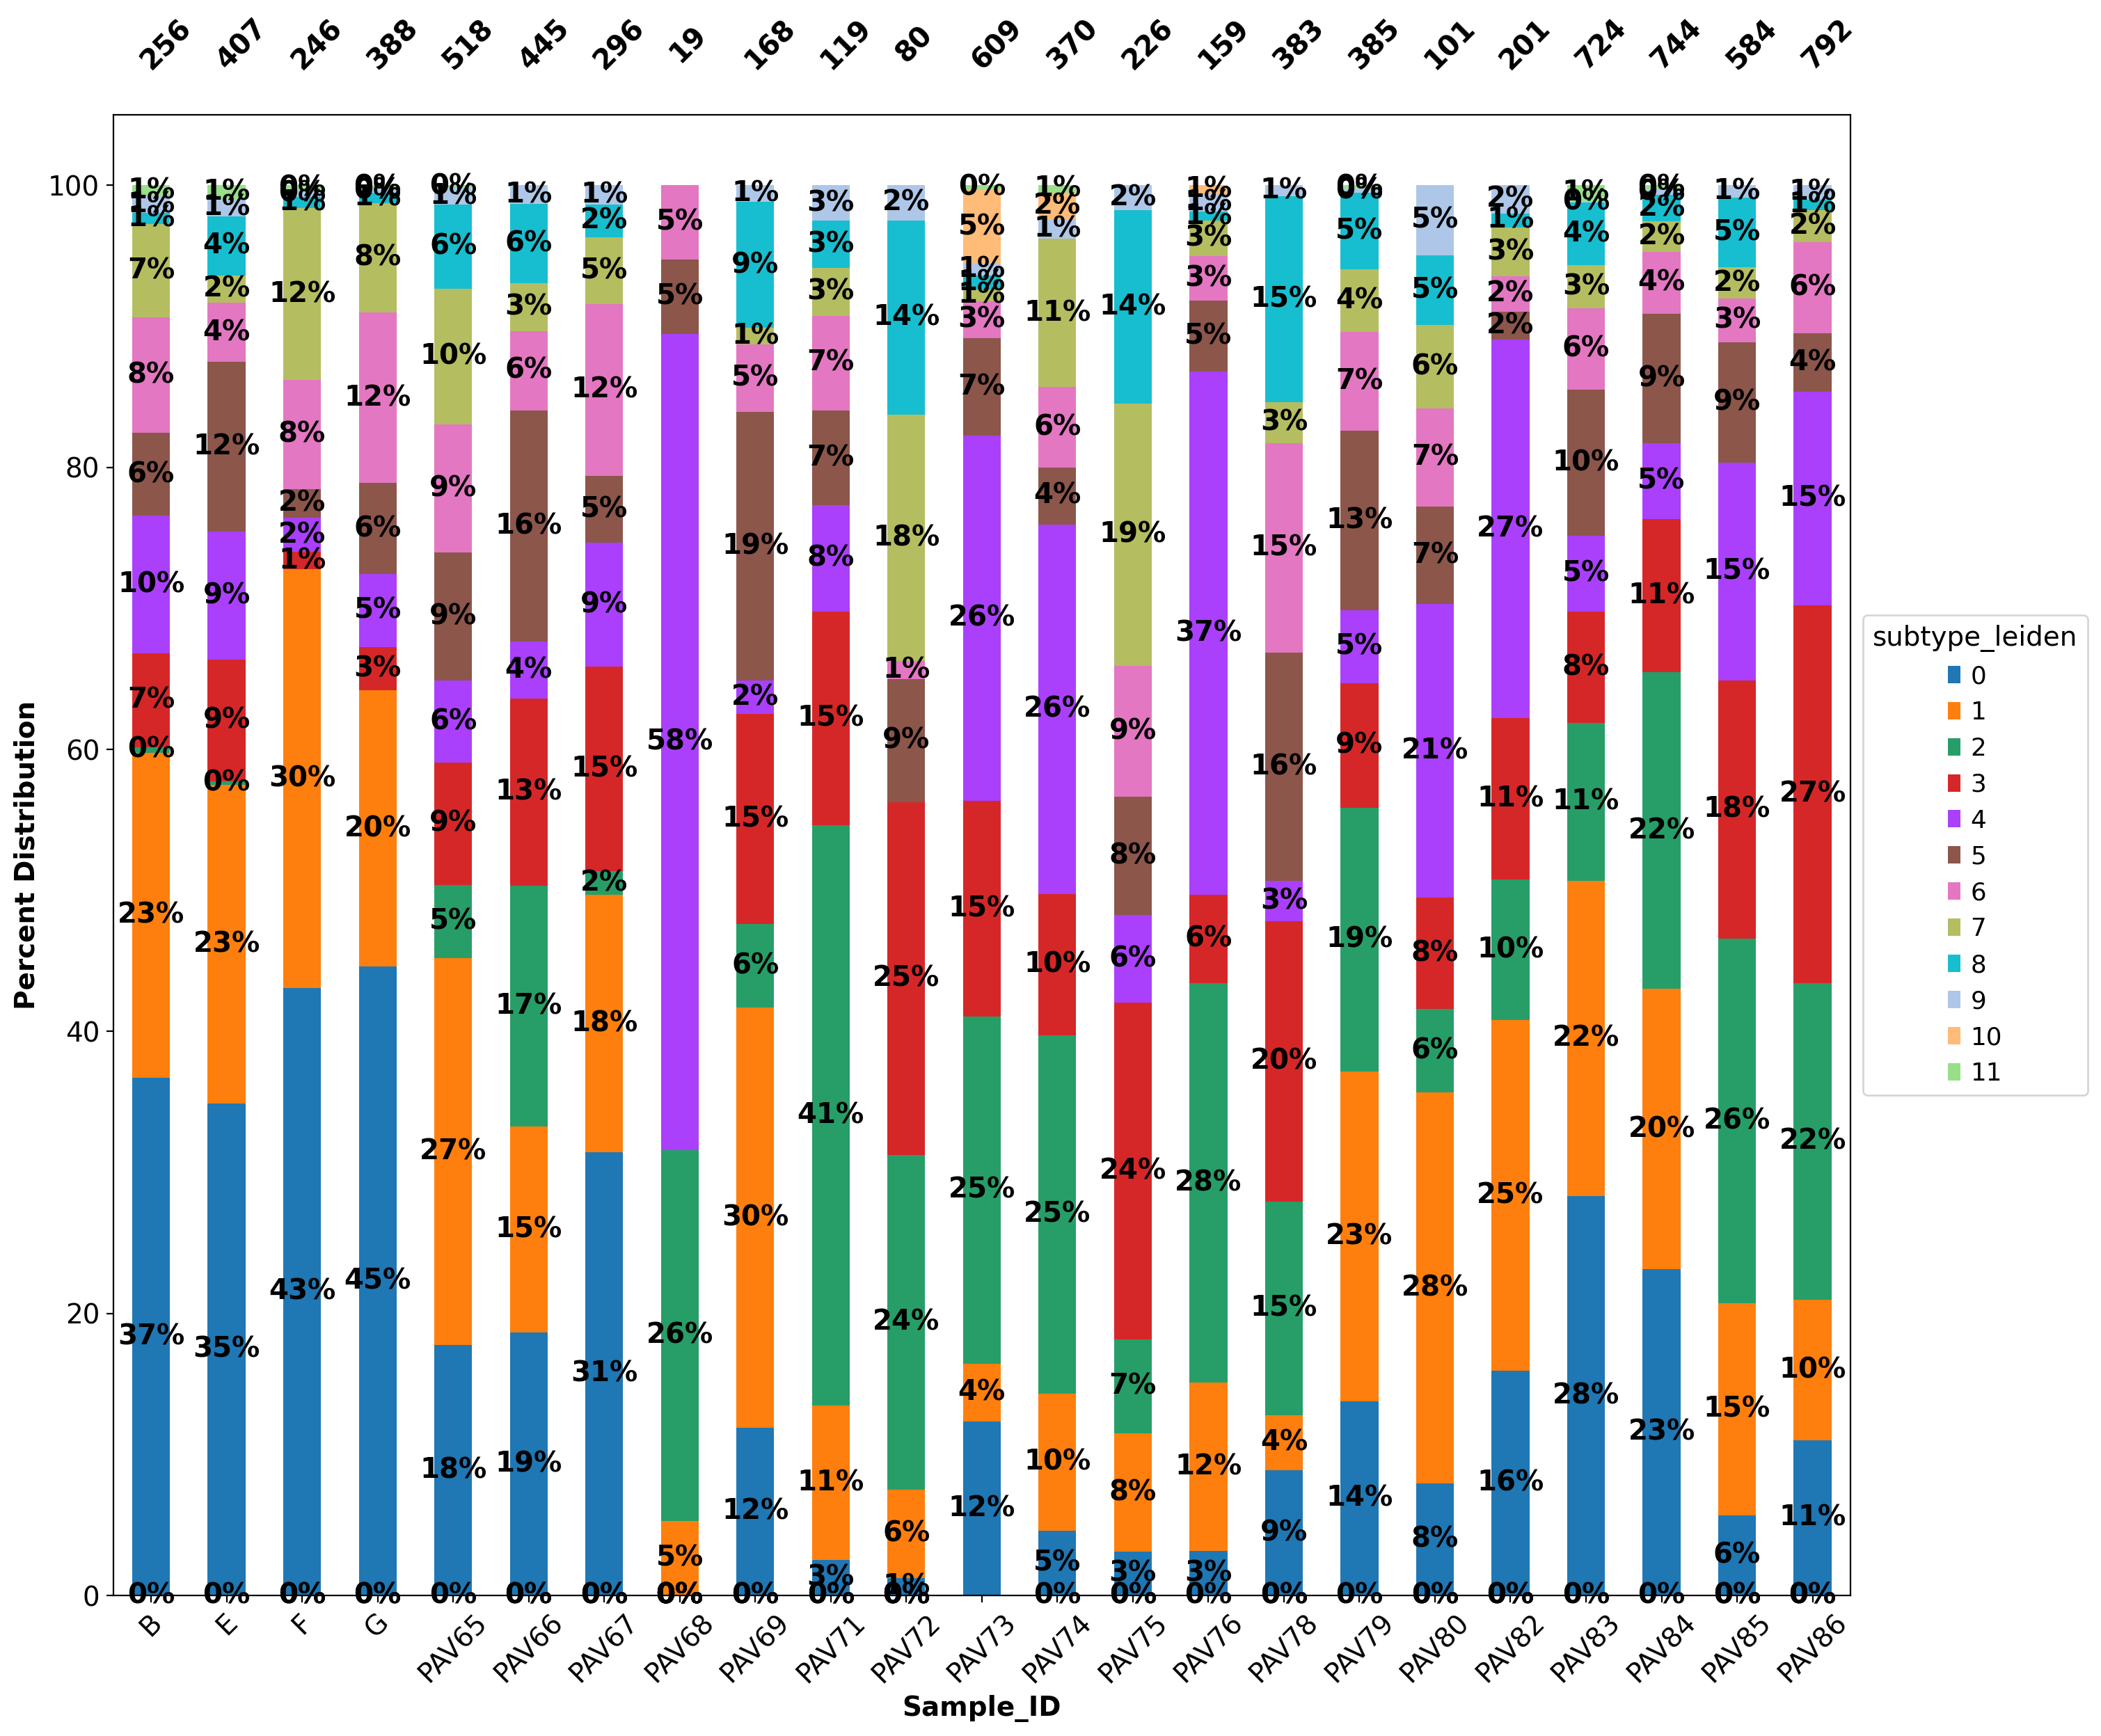

In [23]:
stacked_barplot(preprocessed_EC_adata, 'Sample_ID', 'subtype_leiden', 
                'Sample_ID', 'subtype_leiden', 
                shift_top=0.2, xaxis_rotation=45, 
                figsize=(16,14), percent=True)

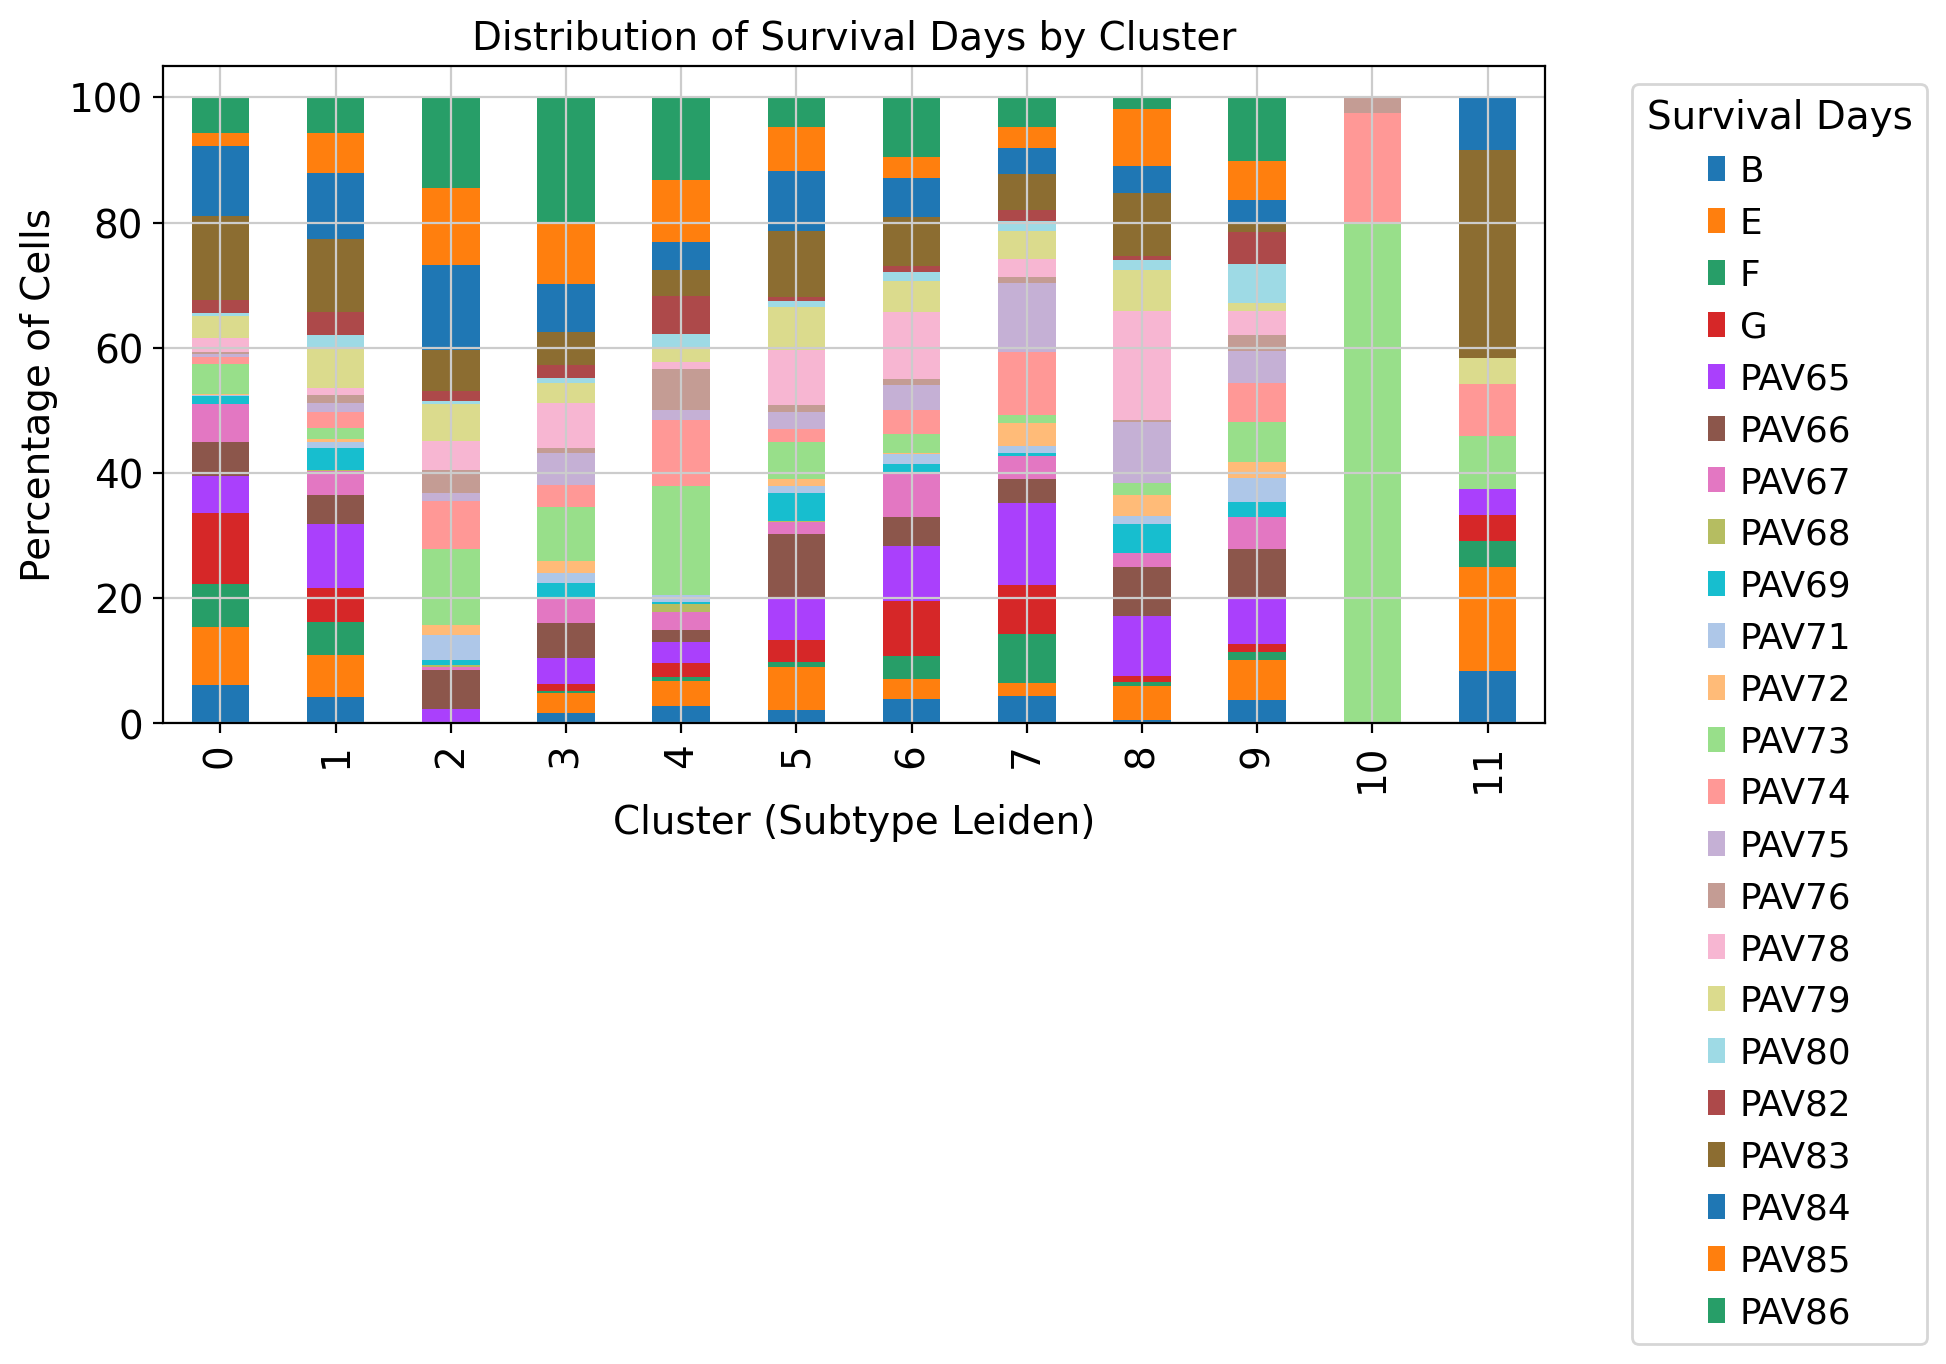

In [24]:
# Extract relevant data
obs_data = preprocessed_EC_adata.obs[['subtype_leiden', 'Sample_ID']]

# Group by 'subtype_leiden' and calculate the percentage of each 'Survival' day
grouped_data = obs_data.groupby('subtype_leiden')['Sample_ID'].value_counts(normalize=True).unstack().fillna(0) * 100

# Plotting
ax = grouped_data.plot(kind='bar', stacked=True, figsize=(10, 6))
ax.set_xlabel('Cluster (Subtype Leiden)')
ax.set_ylabel('Percentage of Cells')
ax.set_title('Distribution of Survival Days by Cluster')
plt.legend(title='Survival Days', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show the plot
plt.show()


In [25]:
preprocessed_EC_adata

AnnData object with n_obs × n_vars = 8220 × 53826
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'pCMV_score', 'n_counts_pCMV', 'leiden_02', 'cell_type', 'Treatment', 'Survival', 'Endpoint_status', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'subtype_leiden'
    var: 'Average_expression', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'mean', 'std'
    uns: 'Sample_ID_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'subtype_leiden', 'subtype_leiden_colors', 'umap', 'wilcoxon'
    obsm: 'X_pca', 'X_umap'

In [26]:
def filter_by_expression(adata_obj, DE_column, key='wilcoxon'):
#adata_obj=fbs_new_harmony.copy()
#key='rank_genes_groups'
#DE_column='leiden'
    def to_tensor(dataframe, columns = [], dtypes = {}, index = False):
        to_records_kwargs = {'index': index}
        if not columns:  # Default to all `dataframe.columns`
            columns = dataframe.columns
        if dtypes:       # Pull in modifications only for dtypes listed in `columns`
            to_records_kwargs['column_dtypes'] = {}
            for column in dtypes.keys():
                if column in columns:
                    to_records_kwargs['column_dtypes'].update({column: dtypes.get(column)})
        return dataframe[columns].to_records(**to_records_kwargs)
    gene_names = pd.DataFrame(adata_obj.uns[key]['names'])
    fraction_in_cluster_matrix = pd.DataFrame(
                np.zeros(gene_names.shape),
                columns=gene_names.columns,
                index=gene_names.index,
            )
    fraction_notin_cluster_matrix = pd.DataFrame(
                np.zeros(gene_names.shape),
                columns=gene_names.columns,
                index=gene_names.index,
            )
    in_cluster_expr_matrix = pd.DataFrame(
                np.zeros(gene_names.shape),
                columns=gene_names.columns,
                index=gene_names.index,
            )
    notin_cluster_matrix = pd.DataFrame(
                np.zeros(gene_names.shape),
                columns=gene_names.columns,
                index=gene_names.index,
            )
    allin_cluster_expr_matrix = pd.DataFrame(
                np.zeros(gene_names.shape),
                columns=gene_names.columns,
                index=gene_names.index,
            )
    allnotin_cluster_matrix = pd.DataFrame(
                np.zeros(gene_names.shape),
                columns=gene_names.columns,
                index=gene_names.index,
            )
    # Create a Adata raw with raw in .X -> We might remove this step - redundant!
    dummy=anndata.AnnData(X=adata_obj.raw.X,
                   var=adata_obj.raw.var,
                   obs=adata_obj.obs)
    # We split the adata by Cell-type. Genes are ordered according to ranks from DEgene analysis
    dummy_split=[dummy[dummy.obs[DE_column].isin([i]),
                  gene_names[i]] for i in gene_names.columns]
    dummy_split_adatasize=[i.shape[0] for i in dummy_split] # How many cells we have in-cluster
    dummy_outcluster=[dummy[~dummy.obs[DE_column].isin([i]),
                       gene_names[i]] for i in gene_names.columns]
    dummy_split_adatasize_outcluster=[i.shape[0] for i in dummy_outcluster] # How many cells we have in out-cluster
    for adata, sizeof_adata, adata_outcluster, sizeof_adata_outcluster in zip(dummy_split, dummy_split_adatasize, 
                                                     dummy_outcluster, dummy_split_adatasize_outcluster):
        cluster_number=[(adata.obs[DE_column].unique()).tolist()][0]
        #incluster_rows, incluster_cols=adata.X.nonzero()
        #https://stackoverflow.com/questions/3797158/counting-non-zero-elements-within-each-row-and-within-each-column-of-a-2d-numpy
        #incluster_counts = [len(np.where(incluster_cols==i)[0]) for i in range(0,adata.shape[1])]
        incluster_counts=np.diff(adata.X.tocsc().indptr)
        percent_expression_incluster=np.array(incluster_counts)/sizeof_adata 
        fraction_in_cluster_matrix[cluster_number[0]]=percent_expression_incluster
        #outcluster_rows, outcluster_cols=adata_outcluster.X.nonzero()
        #outcluster_counts = [len(np.where(outcluster_cols==i)[0]) for i in range(0,adata_outcluster.shape[1])]
        outcluster_counts=np.diff(adata_outcluster.X.tocsc().indptr)
        percent_expression_outcluster=np.array(outcluster_counts)/sizeof_adata_outcluster 
        fraction_notin_cluster_matrix[cluster_number[0]]=percent_expression_outcluster
        # Expression_all in cluster
        allin_cluster_expr_matrix[cluster_number[0]]=np.squeeze(np.asarray(adata.X.mean(axis=0)))
        allnotin_cluster_matrix[cluster_number[0]]=np.squeeze(np.asarray(adata_outcluster.X.mean(axis=0)))
    # Generate the last table results
    result = adata_obj.uns['wilcoxon']
    groups = result['names'].dtype.names
    result['pi'] = to_tensor(fraction_in_cluster_matrix)
    result['po'] = to_tensor(fraction_notin_cluster_matrix)
    result['ei'] = to_tensor(allin_cluster_expr_matrix)
    result['eo'] = to_tensor(allnotin_cluster_matrix)
    results =pd.DataFrame(
        {group + '_' + key[:2]: result[key][group]
        for group in groups for key in ['names', 'pvals_adj', 'logfoldchanges', 'pi', 'po', "ei", "eo"]})
    return results

In [35]:
def makevector_topmarkers(dea_adata, top_n, ldFC_cutoff=0.5, pvals_adj_cutoff=10**-30): 
    # Access the 'wilcoxon' results from the uns attribute of the AnnData object
    results = dea_adata.uns['wilcoxon']  
    
    # Get the list of clusters from the DE results
    clusters = results['names'].dtype.names
    
    # Initialize an empty DataFrame to store top genes for each cluster
    top_genes_dict = {}

    # Loop through each cluster to get the top markers
    for cluster in clusters:
        # Filter the top genes based on log fold-change and adjusted p-values
        topgenes_cluster = results['names'][cluster][np.where(
            (results['logfoldchanges'][cluster] >= ldFC_cutoff) &
            (results['pvals_adj'][cluster] < pvals_adj_cutoff)
        )][:top_n]
        
        # Save the top genes for the current cluster
        top_genes_dict[cluster] = topgenes_cluster.tolist()

    # Convert to a DataFrame
    top_genes_df = pd.DataFrame.from_dict(top_genes_dict, orient='index').T
    return top_genes_df

# Example usage
DEGs_xeno = makevector_topmarkers(dea_adata, top_n=20, ldFC_cutoff=0.5, pvals_adj_cutoff=10**-30)

# Save the results for each cluster as separate CSV files
save_path = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/results v2.1/ei-eo-pi-po full all clusters"
for cluster in DEGs_xeno.columns:
    cluster_data = DEGs_xeno[[cluster]].dropna()  # Filter data for the cluster
    cluster_data.to_csv(f"{save_path}DEGs_cluster_{cluster}.csv", index=False)

In [24]:
DEGs_xeno=filter_by_expression(dea_adata, 'subtype_leiden', key='wilcoxon')
DEGs_xeno.head()

,0_na,0_pv,0_lo,0_pi,0_po,0_ei,0_eo,1_na,1_pv,1_lo,...,10_po,10_ei,10_eo,11_na,11_pv,11_lo,11_pi,11_po,11_ei,11_eo
0,Sus_scrofa___ADGRF5,1.128834e-164,1.877021,0.882736,0.664174,3.153745,1.960757,Sus_scrofa___IL1R1,2.426491e-126,4.113204,...,0.000611,2.860518,0.001557,Sus_scrofa___CD163,0.011987,7.002993,0.625000,0.018302,1.935558,0.045180
1,Sus_scrofa___FOXN3,3.060397e-119,1.459086,0.835179,0.678833,2.777536,1.869448,Sus_scrofa___ADGRG6,2.165957e-124,4.073830,...,0.000733,3.059047,0.001771,Sus_scrofa___RBPJ,1.000000,3.057127,0.583333,0.214861,1.794960,0.471905
2,Sus_scrofa___FRYL,5.575499e-112,1.347635,0.857980,0.707554,2.842922,1.994989,Sus_scrofa___FBN1,1.542677e-120,2.131310,...,0.001222,3.055747,0.003494,Sus_scrofa___RESF1,1.000000,1.842245,0.750000,0.433870,2.138482,1.127493
3,Sus_scrofa___LRMDA,5.575499e-112,1.481957,0.848860,0.700075,3.130747,2.178952,Sus_scrofa___SLCO2A1,4.705616e-117,2.184688,...,0.000611,3.117513,0.001478,Sus_scrofa___F13A1,1.000000,6.444785,0.375000,0.008663,1.013959,0.019963
4,Sus_scrofa___ABLIM3,3.839856e-110,1.578671,0.844300,0.645774,2.895179,1.905156,Sus_scrofa___LDB2,1.622149e-109,1.910089,...,0.000733,3.440050,0.001549,Sus_scrofa___SLC39A11,1.000000,2.072411,0.583333,0.259761,1.484682,0.594219


In [3]:
# import pandas as pd
# import os

# # Define the output directory where DEG results will be saved
# output_dir = '/data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/results v2.1/ei-eo-pi-po full DEG results/'
# os.makedirs(output_dir, exist_ok=True)  # Ensure the output directory exists

# # Function to save full DEG results for each cluster
# def save_full_deg_results(dea_adata, save_path):
#     # Access the 'wilcoxon' results from the uns attribute of the AnnData object
#     results = dea_adata.uns['wilcoxon']  
    
#     # Get the list of clusters from the DE results
#     clusters = results['names'].dtype.names
    
#     # Loop through each cluster to get and save full marker data
#     for cluster in clusters:
#         # Create a DataFrame with all relevant data for the cluster
#         cluster_data = pd.DataFrame({
#             "names": results["names"][cluster],
#             "logfoldchanges": results["logfoldchanges"][cluster],
#             "pvals": results["pvals"][cluster],
#             "pvals_adj": results["pvals_adj"][cluster],
#             "pi": results["pi"][cluster],
#             "po": results["po"][cluster],
#             "ei": results["ei"][cluster],
#             "eo": results["eo"][cluster],
#         })
        
#         # Sort by the p-values to rank the genes
#         ranked_cluster_data = cluster_data.sort_values(by="pvals", ascending=True)
        
#         # Save the ranked results to a CSV file for the current cluster
#         output_file = os.path.join(save_path, f"Full_DEGs_cluster_{cluster}.csv")
#         ranked_cluster_data.to_csv(output_file, index=False)
#         print(f"Saved full DEG results for cluster {cluster} to {output_file}")

# # Example usage
# save_full_deg_results(dea_adata, save_path=output_dir)


In [68]:
DEGs_xeno=filter_by_expression(dea_adata, 'subtype_leiden', key='wilcoxon')
DEGs_xeno.head()

,0_na,0_pv,0_lo,0_pi,0_po,0_ei,0_eo,1_na,1_pv,1_lo,...,10_po,10_ei,10_eo,11_na,11_pv,11_lo,11_pi,11_po,11_ei,11_eo
0,Sus_scrofa___ADGRF5,1.128834e-164,1.877021,0.882736,0.664174,3.153745,1.960757,Sus_scrofa___IL1R1,2.426491e-126,4.113204,...,0.000611,2.860518,0.001557,Sus_scrofa___CD163,0.011987,7.002993,0.625000,0.018302,1.935558,0.045180
1,Sus_scrofa___FOXN3,3.060397e-119,1.459086,0.835179,0.678833,2.777536,1.869448,Sus_scrofa___ADGRG6,2.165957e-124,4.073830,...,0.000733,3.059047,0.001771,Sus_scrofa___RBPJ,1.000000,3.057127,0.583333,0.214861,1.794960,0.471905
2,Sus_scrofa___FRYL,5.575499e-112,1.347635,0.857980,0.707554,2.842922,1.994989,Sus_scrofa___FBN1,1.542677e-120,2.131310,...,0.001222,3.055747,0.003494,Sus_scrofa___RESF1,1.000000,1.842245,0.750000,0.433870,2.138482,1.127493
3,Sus_scrofa___LRMDA,5.575499e-112,1.481957,0.848860,0.700075,3.130747,2.178952,Sus_scrofa___SLCO2A1,4.705616e-117,2.184688,...,0.000611,3.117513,0.001478,Sus_scrofa___F13A1,1.000000,6.444785,0.375000,0.008663,1.013959,0.019963
4,Sus_scrofa___ABLIM3,3.839856e-110,1.578671,0.844300,0.645774,2.895179,1.905156,Sus_scrofa___LDB2,1.622149e-109,1.910089,...,0.000733,3.440050,0.001549,Sus_scrofa___SLC39A11,1.000000,2.072411,0.583333,0.259761,1.484682,0.594219


In [39]:
preprocessed_EC_adata

AnnData object with n_obs × n_vars = 8220 × 53826
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'pCMV_score', 'n_counts_pCMV', 'leiden_02', 'cell_type', 'Treatment', 'Survival', 'Endpoint_status', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'subtype_leiden'
    var: 'Average_expression', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'mean', 'std'
    uns: 'Sample_ID_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'subtype_leiden', 'subtype_leiden_colors', 'umap', 'wilcoxon'
    obsm: 'X_pca', 'X_umap'

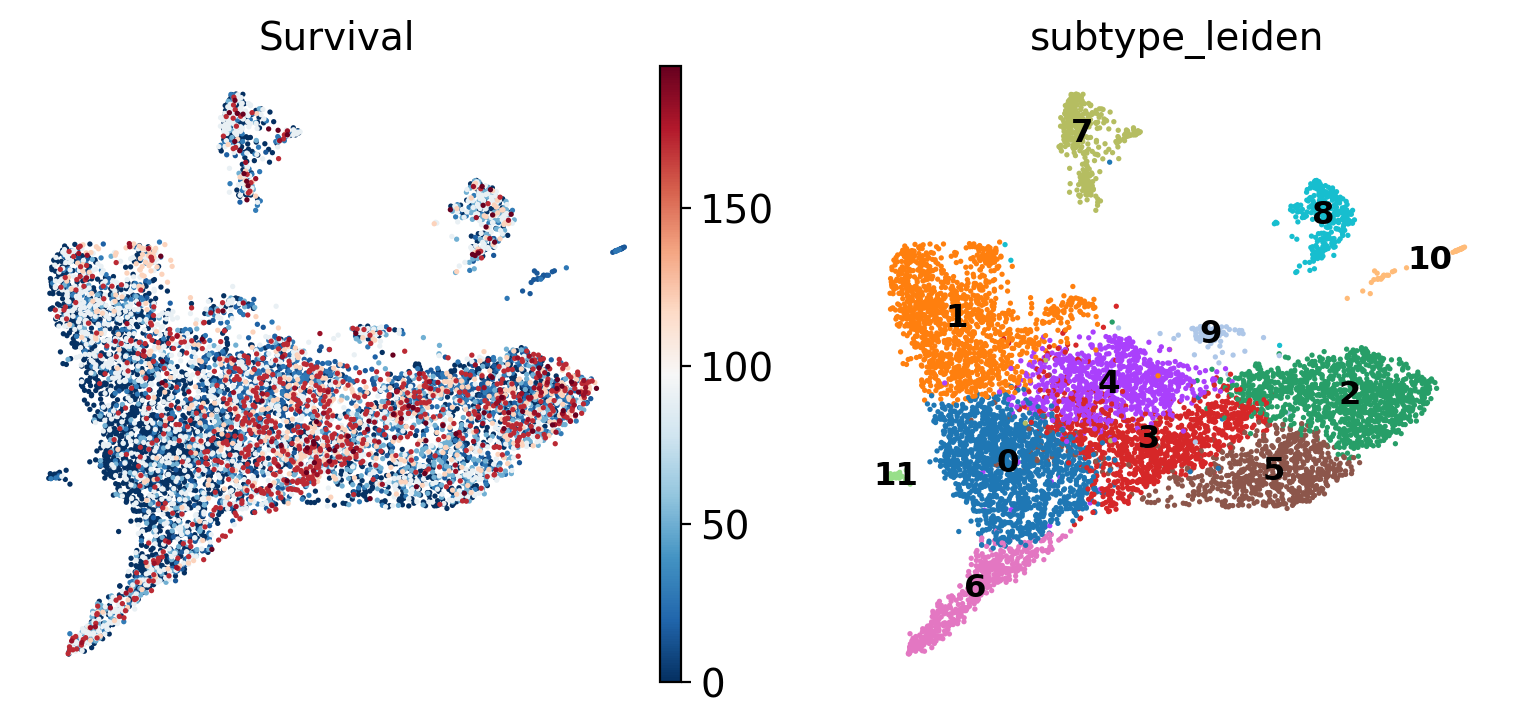

In [79]:
sc.pl.umap(
    preprocessed_EC_adata,  # Use the entire dataset
    color=['Survival', 'subtype_leiden'],  # Visualize 'Survival' and clusters from 'subtype_leiden'
    projection="2d", 
    components=['1,2'], 
    show=True, 
    legend_fontsize="small", 
    legend_loc="on data",  # Place the legend on the plot
    frameon=False
)

In [48]:
# Step 1: Access the current 'subtype_leiden' column and convert it to string type
merged_clusters = preprocessed_EC_adata.obs['subtype_leiden'].astype(str)

# Step 2: Define cluster merging
# Replace specific clusters based on the mapping
cluster_merge_mapping = {
    '0': 'Cluster_0_11',    # Merge cluster 0 with 11
    '2': 'Cluster_2_3',     # Merge cluster 2 with 3
    '3': 'Cluster_2_3',
    '11': 'Cluster_0_11'
}
merged_clusters.replace(cluster_merge_mapping, inplace=True)

# Step 3: Save the merged clusters to a new column
preprocessed_EC_adata.obs['subtype_leiden2'] = merged_clusters

# Step 4: Renumber clusters in sequential order
# Extract unique merged cluster labels, sort them, and assign new numeric labels
unique_clusters = np.sort(preprocessed_EC_adata.obs['subtype_leiden2'].unique())
new_cluster_labels = {old_label: str(new_label) for new_label, old_label in enumerate(unique_clusters)}

# Reassign new numeric labels
preprocessed_EC_adata.obs['subtype_leiden2'] = preprocessed_EC_adata.obs['subtype_leiden2'].map(new_cluster_labels)

# (Optional) Verify the changes
print(preprocessed_EC_adata.obs['subtype_leiden2'].value_counts())


subtype_leiden2
9    2299
8    1559
0    1389
2     909
3     708
4     533
5     384
6     320
7      79
1      40
Name: count, dtype: int64


In [50]:
merged_EC_adata = preprocessed_EC_adata.write ('/data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/data v2.1/merged_EC_adata.h5ad')

In [26]:
merged_EC_adata = sc.read('/data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/data v2.1/merged_EC_adata.h5ad')

In [27]:
# Get the current 'subtype_leiden' column
merged_clusters = preprocessed_EC_adata.obs['subtype_leiden'].astype(str)

# Merging clusters as needed
merged_clusters.replace({'0': 'Cluster_0_11',
                         '2': 'Cluster_2_3',
                         '3': 'Cluster_2_3',
                         '11': 'Cluster_0_11'
                         }, inplace=True)

# Save the merged clusters in a new column
preprocessed_EC_adata.obs['subtype_leiden2'] = merged_clusters

# Now, renumber the clusters in sequential order: 0, 1, 2, 3, ...
# Get unique cluster labels and create a mapping to new numeric labels
unique_clusters = np.sort(preprocessed_EC_adata.obs['subtype_leiden2'].unique())
new_cluster_labels = {old_label: str(new_label) for new_label, old_label in enumerate(unique_clusters)}

# Re-assign the new numeric labels to the 'subtype_leiden2' column
preprocessed_EC_adata.obs['subtype_leiden2'] = preprocessed_EC_adata.obs['subtype_leiden2'].map(new_cluster_labels)

In [28]:
merged_EC_adata

AnnData object with n_obs × n_vars = 8220 × 53826
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'pCMV_score', 'n_counts_pCMV', 'leiden_02', 'cell_type', 'Treatment', 'Survival', 'Endpoint_status', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'subtype_leiden', 'subtype_leiden2'
    var: 'Average_expression', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'mean', 'std'
    uns: 'Sample_ID_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'subtype_leiden', 'subtype_leiden2_colors', 'subtype_leiden_colors', 'umap', 'wilcoxon'
    obsm: 'X_pca'

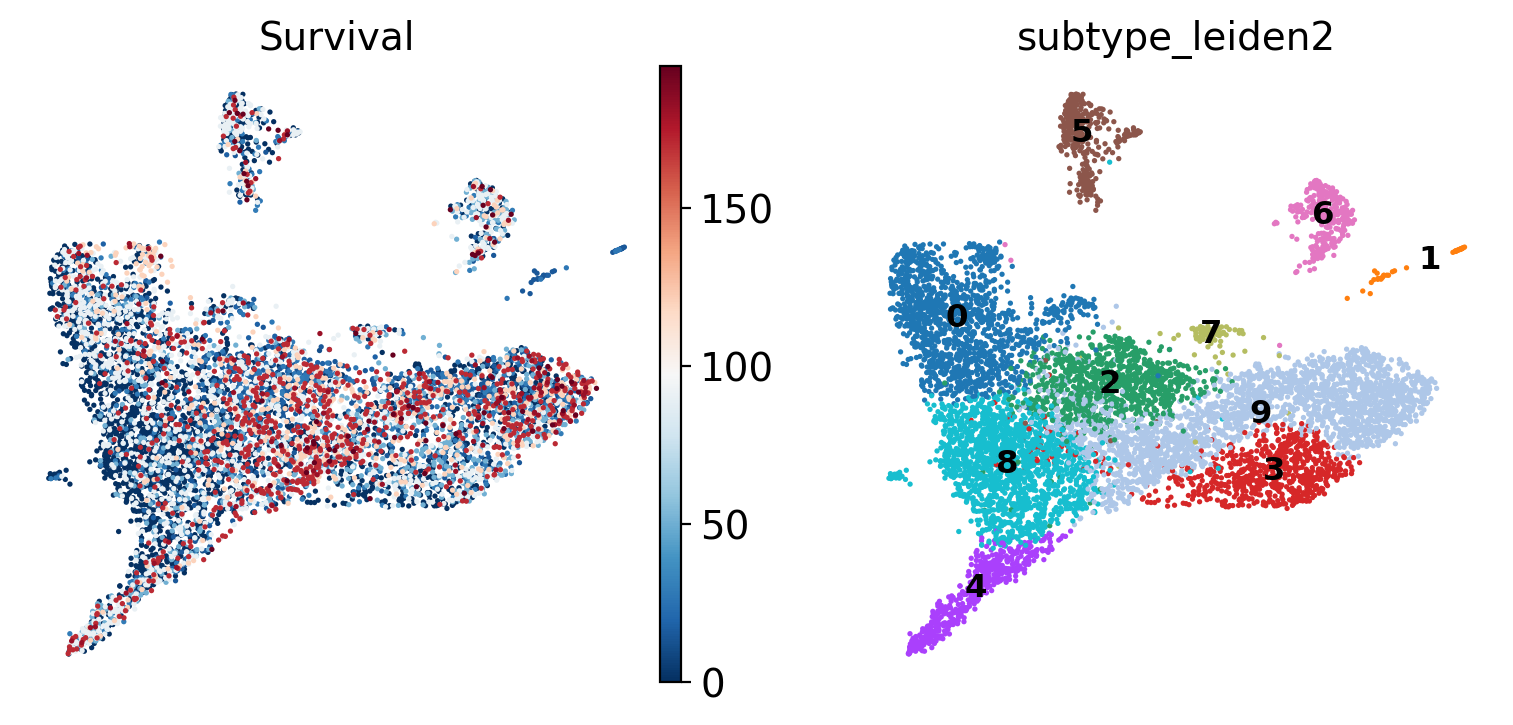

In [48]:
sc.pl.umap(
    merged_EC_adata,  # Use the entire dataset
    color=['Survival', 'subtype_leiden2'],  # Visualize 'Survival' and clusters from 'subtype_leiden'
    projection="2d", 
    components=['1,2'], 
    show=True, 
    legend_fontsize="small", 
    legend_loc="on data",  # Place the legend on the plot
    frameon=False
)

In [31]:
cluster_annotations = {
    "0": "Proinflammatory EC",
    "1": "pCMV+ ECs",
    "2": "IFN+ capillary ECs",
    "3": "Angiogenic EC-1 (arterial)",
    "4": "Arterial ECs",
    "5": "Mesothelial ECs",
    "6": "Proliferative ECs",
    "7": "NFKB+ ECs",
    "8": "Capillary ECs",
    "9": "Angiogenic EC-2 (hypoxic)"
}

In [32]:
# Add the manual annotations to the 'merged_EC_adata' object
merged_EC_adata.obs["EC_subtype_annotation"] = merged_EC_adata.obs.subtype_leiden2.astype(str).map(cluster_annotations)

In [5]:
# import colorcet as cc
# import scanpy as sc # Define the large palette using Colorcet's glasbey_light palette
# large_palette = sns.color_palette(cc.glasbey_light, n_colors=120)

# # Manually choose specific colors for each cell type from large_palette
# celltype_colors = {
#     "Proinflammatory EC": large_palette[29],
#     "pCMV+ ECs": large_palette[0],
#     "IFN+ capillary ECs": large_palette[5],
#     "Angiogenic EC-1 (arterial)": large_palette[6],
#     "Arterial ECs": large_palette[87],
#     "Mesothelial ECs": large_palette[56],
#     "Proliferative ECs": large_palette[3],
#     "NFKB+ ECs": large_palette[51],
#     "Capillary ECs": large_palette[43],
#     "Angiogenic EC-2 (hypoxic)": large_palette[35]
# }

# actual_cell_types = merged_EC_adata.obs['EC_subtype_annotation'].cat.categories

# # Ensure color assignment matches the actual cell types
# ordered_colors = [celltype_colors[celltype] for celltype in actual_cell_types]


# fig, ax = plt.subplots(figsize=(8, 7))  # Adjust the size of the figure if needed

# # Plotting the UMAP with the specific color palette
# sc.pl.umap(merged_EC_adata, color='EC_subtype_annotation',
#            palette=ordered_colors, legend_loc='on data', legend_fontsize=10,
#            frameon=True, title='EC Subtype Annotation', ax=ax, show=False)

# # Save this UMAP with chosen colors
# plt.savefig('/data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/results v2.1/Manual_annotation_EC.png', dpi=400, bbox_inches='tight')

# # Show the figure
# plt.show()

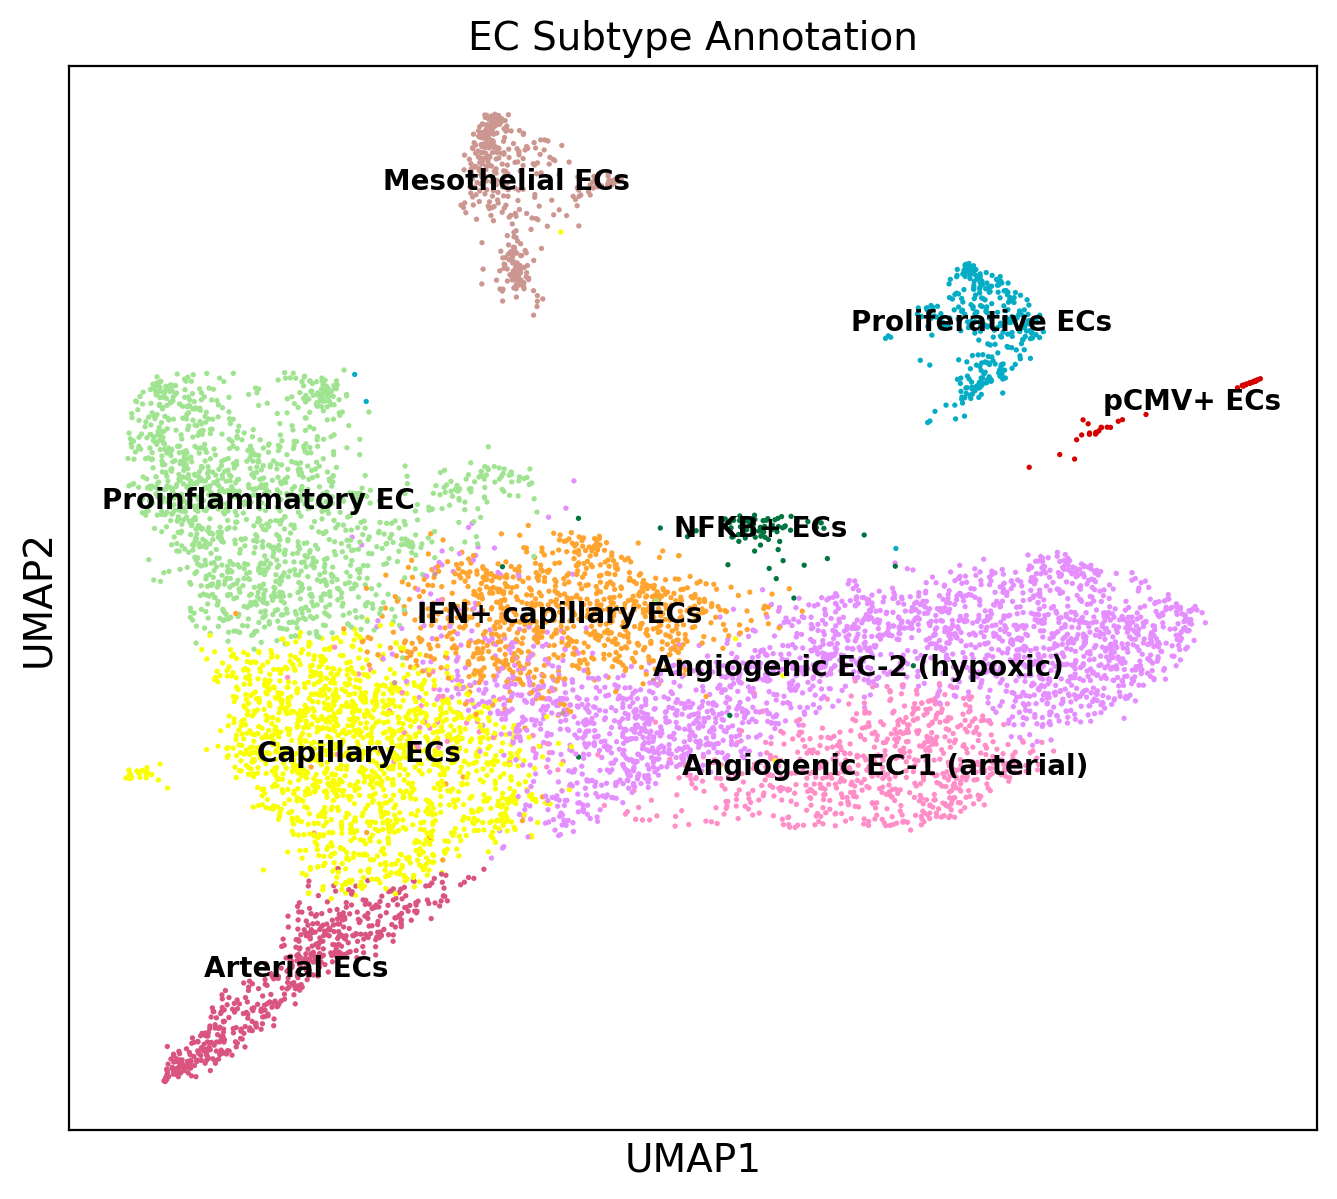

In [127]:
import colorcet as cc
import scanpy as sc # Define the large palette using Colorcet's glasbey_light palette
large_palette = sns.color_palette(cc.glasbey_light, n_colors=120)

# Manually choose specific colors for each cell type from large_palette
celltype_colors = {
    "Proinflammatory EC": large_palette[29],
    "pCMV+ ECs": large_palette[0],
    "IFN+ capillary ECs": large_palette[5],
    "Angiogenic EC-1 (arterial)": large_palette[6],
    "Arterial ECs": large_palette[87],
    "Mesothelial ECs": large_palette[56],
    "Proliferative ECs": large_palette[3],
    "NFKB+ ECs": large_palette[51],
    "Capillary ECs": large_palette[43],
    "Angiogenic EC-2 (hypoxic)": large_palette[35]
}

actual_cell_types = merged_EC_adata.obs['EC_subtype_annotation'].cat.categories

# Ensure color assignment matches the actual cell types
ordered_colors = [celltype_colors[celltype] for celltype in actual_cell_types]


fig, ax = plt.subplots(figsize=(8, 7))  # Adjust the size of the figure if needed

# Plotting the UMAP with the specific color palette
sc.pl.umap(merged_EC_adata, color='EC_subtype_annotation',
           palette=ordered_colors, legend_loc='on data', legend_fontsize=10,
           frameon=True, title='EC Subtype Annotation', ax=ax, show=False)

# Save this UMAP with chosen colors
plt.savefig('/data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/results v2.1/Manual_annotation_EC.png', dpi=400, bbox_inches='tight')

# Show the figure
plt.show()

In [6]:
annotated_EC_adata = merged_EC_adata.write ('/data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/data v2.1/annotated_EC_adata.h5ad')

In [4]:
annotated_EC_adata = sc.read ('/data2/core-med1/nhadizad/nastaran/Xenotransplant/ECs/v2.1 results & data/final_annotated_EC_object.h5ad')

In [15]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
dimplot_color=mcolors.LinearSegmentedColormap.from_list("custom_cmap", ["#E5E5E5","#FF0000"])

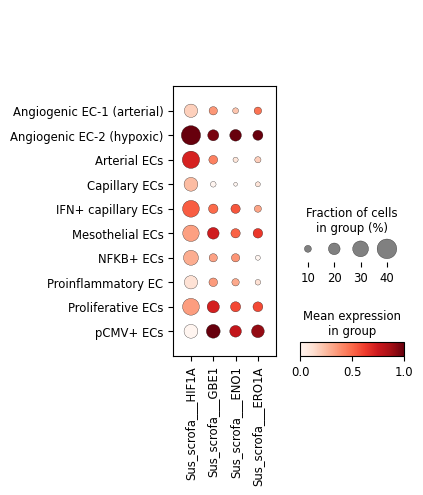

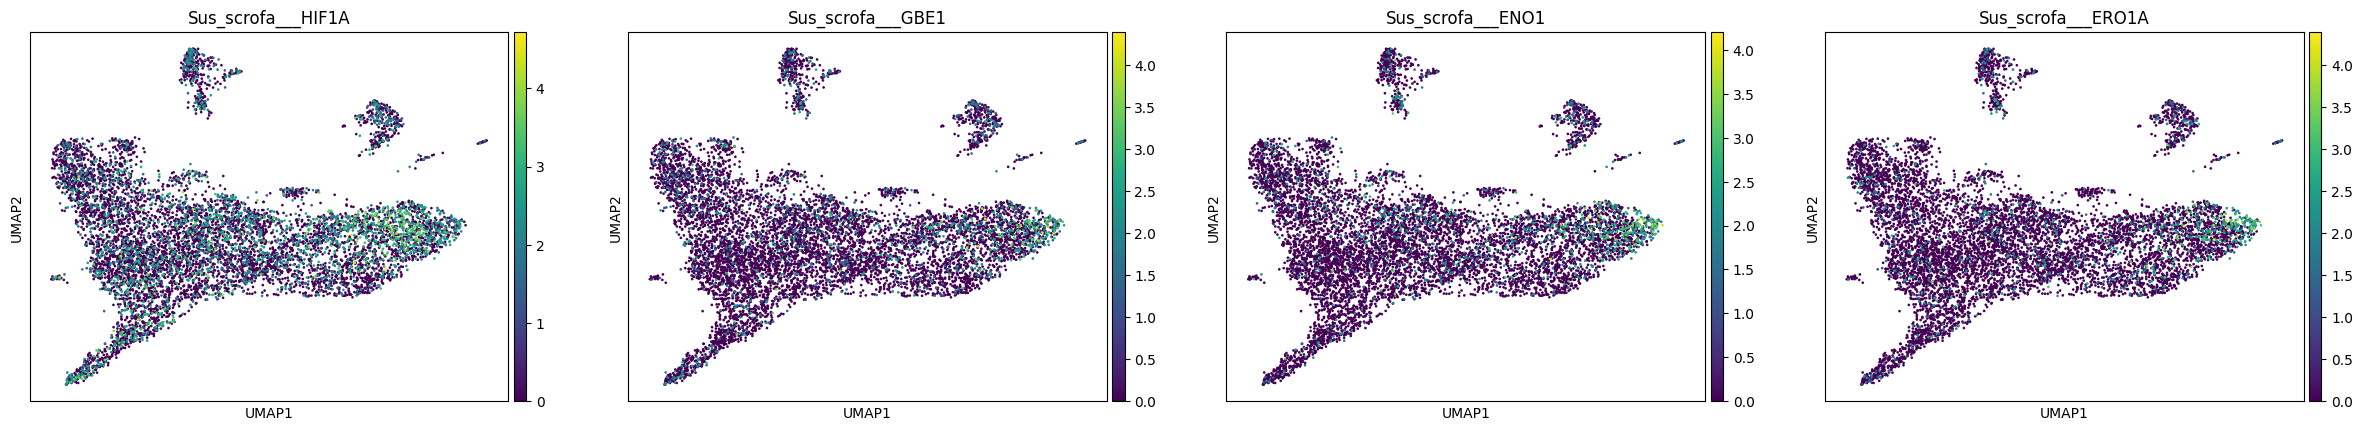

In [19]:
# cluster 2 is definitely inflammatory

genes = [
"Sus_scrofa___HIF1A", 
"Sus_scrofa___GBE1", 
"Sus_scrofa___ENO1", 
"Sus_scrofa___ERO1A",
]

# Create the dot plot
sc.pl.dotplot(annotated_EC_adata, genes, groupby='EC_subtype_annotation', use_raw=True, vmin=0, standard_scale = 'var')

# feature plot

sc.pl.umap(annotated_EC_adata, color=genes,)

ranking genes
    finished: added to `.uns['wilcoxon_ann']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:14)


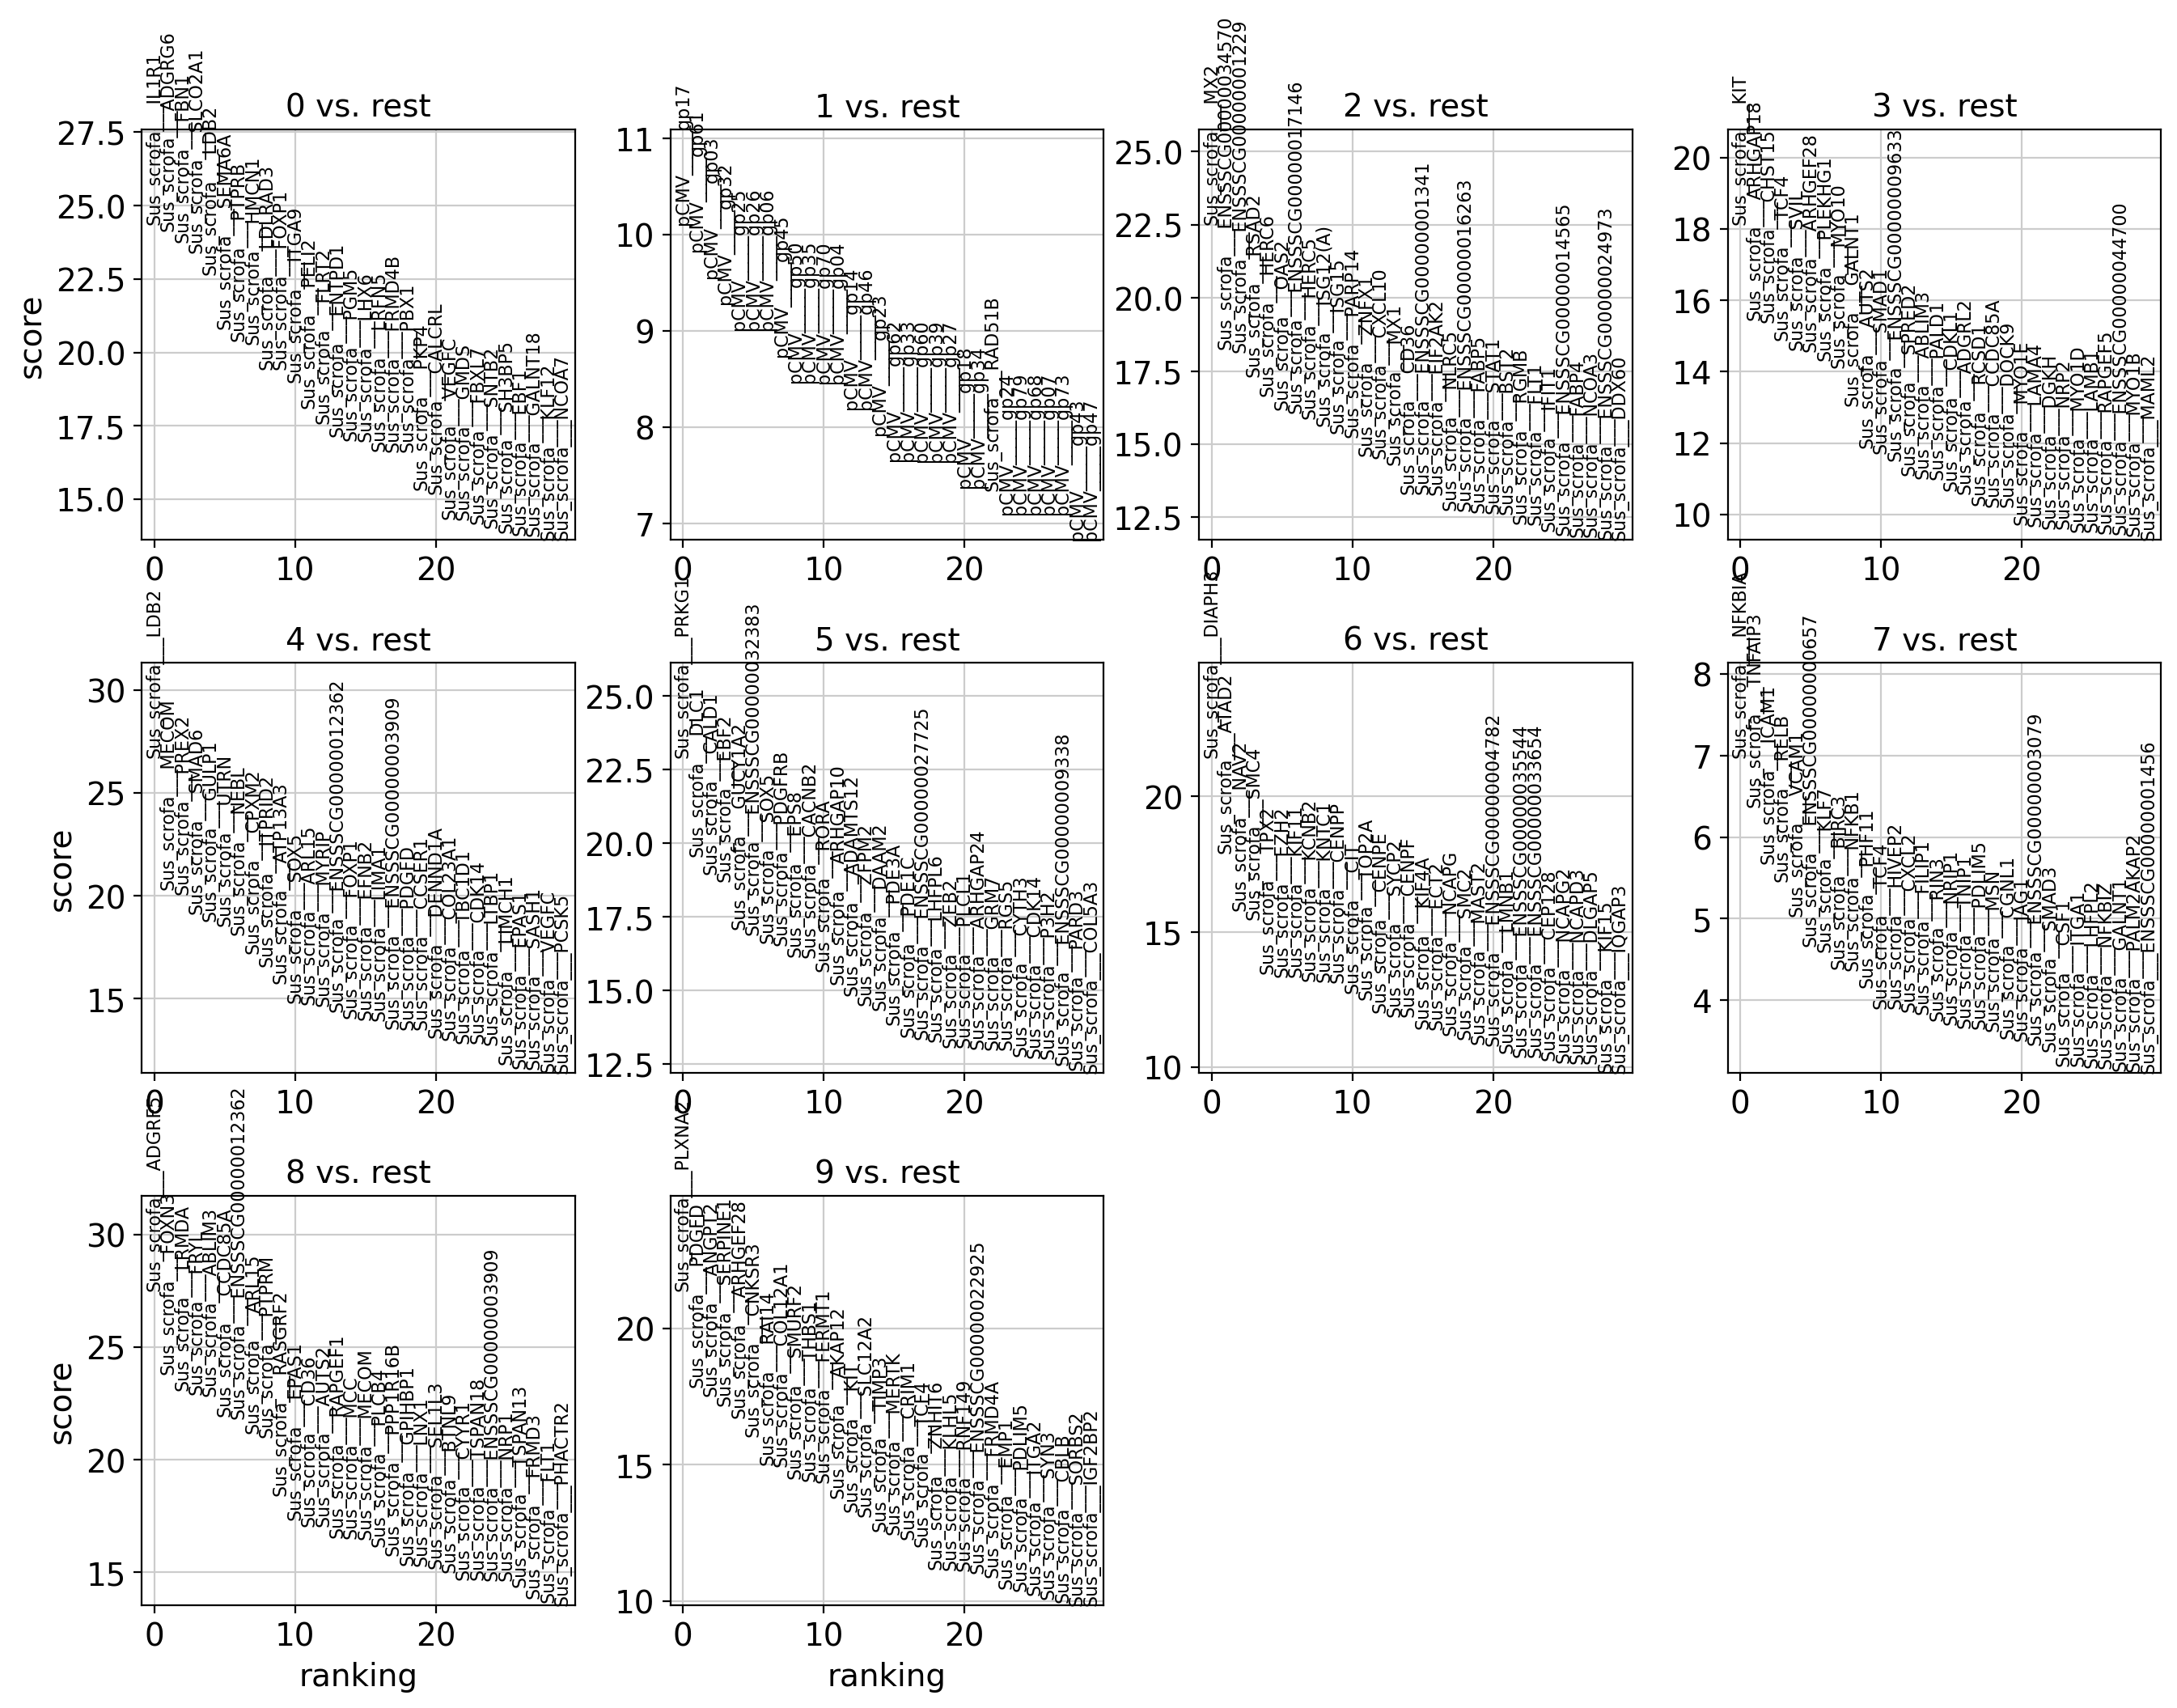

In [149]:
# Perform differential expression to find marker genes for each cluster using Wilcoxon test on raw data
sc.tl.rank_genes_groups(annotated_EC_adata, 'subtype_leiden2', method='wilcoxon', key_added='wilcoxon_ann', use_raw=True)

# Visualize the top marker genes for each cluster
sc.pl.rank_genes_groups(annotated_EC_adata, key='wilcoxon_ann', n_genes=30, sharey=False)

# Save the DE analysis to an H5AD file
annotated_dea_adata = annotated_EC_adata.write('/data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/data v2.1/annotated_DEA_adata.h5ad')

In [4]:
annotated_dea_adata = sc.read ('/data2/core-med1/nhadizad/nastaran/Xenotransplant/ECs/v2.1 results & data/data v2.1/annotated_DEA_adata2.h5ad')

In [40]:
import os
# Define the output directory
output_dir = '/data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/results v2.1/merged annotated results/Complete DEG results/'
os.makedirs(output_dir, exist_ok=True)  # Ensure the output directory exists

# Access the DE results stored in dea_adata.uns['wilcoxon']
de_results = annotated_dea_adata.uns['wilcoxon_ann']

# Extract log-fold changes, p-values, and adjusted p-values
logfoldchanges = de_results['logfoldchanges']
pvals = de_results['pvals']
pvals_adj = de_results['pvals_adj']

# Loop through each cluster and save DEGs to a separate CSV file
for cluster in annotated_dea_adata.obs['EC_subtype_annotation'].cat.categories:
    # Extract the top genes for the current cluster
    gene_names = de_results['names'][cluster]
    logfc = logfoldchanges[cluster]
    pval = pvals[cluster]
    adj_pval = pvals_adj[cluster]
    
    # Create a DataFrame for the cluster's DEGs
    degs_df = pd.DataFrame({
        'Gene': gene_names,
        'LogFoldChange': logfc,
        'PValue': pval,
        'AdjustedPValue': adj_pval
    })
    
    # Save the DataFrame to a CSV file
    output_file = os.path.join(output_dir, f"DEGs_cluster_{cluster}.csv")
    degs_df.to_csv(output_file, index=False)
    print(f"Saved DEGs for cluster {cluster} to {output_file}")


Saved DEGs for cluster Angiogenic EC-1 (arterial) to /data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/results v2.1/merged annotated results/Complete DEG results/DEGs_cluster_Angiogenic EC-1 (arterial).csv
Saved DEGs for cluster Angiogenic EC-2 (hypoxic) to /data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/results v2.1/merged annotated results/Complete DEG results/DEGs_cluster_Angiogenic EC-2 (hypoxic).csv
Saved DEGs for cluster Arterial ECs to /data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/results v2.1/merged annotated results/Complete DEG results/DEGs_cluster_Arterial ECs.csv
Saved DEGs for cluster Capillary ECs to /data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/results v2.1/merged annotated results/Complete DEG results/DEGs_cluster_Capillary ECs.csv
Saved DEGs for cluster IFN+ capillary ECs to /data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/results v2.1/merged annotated results

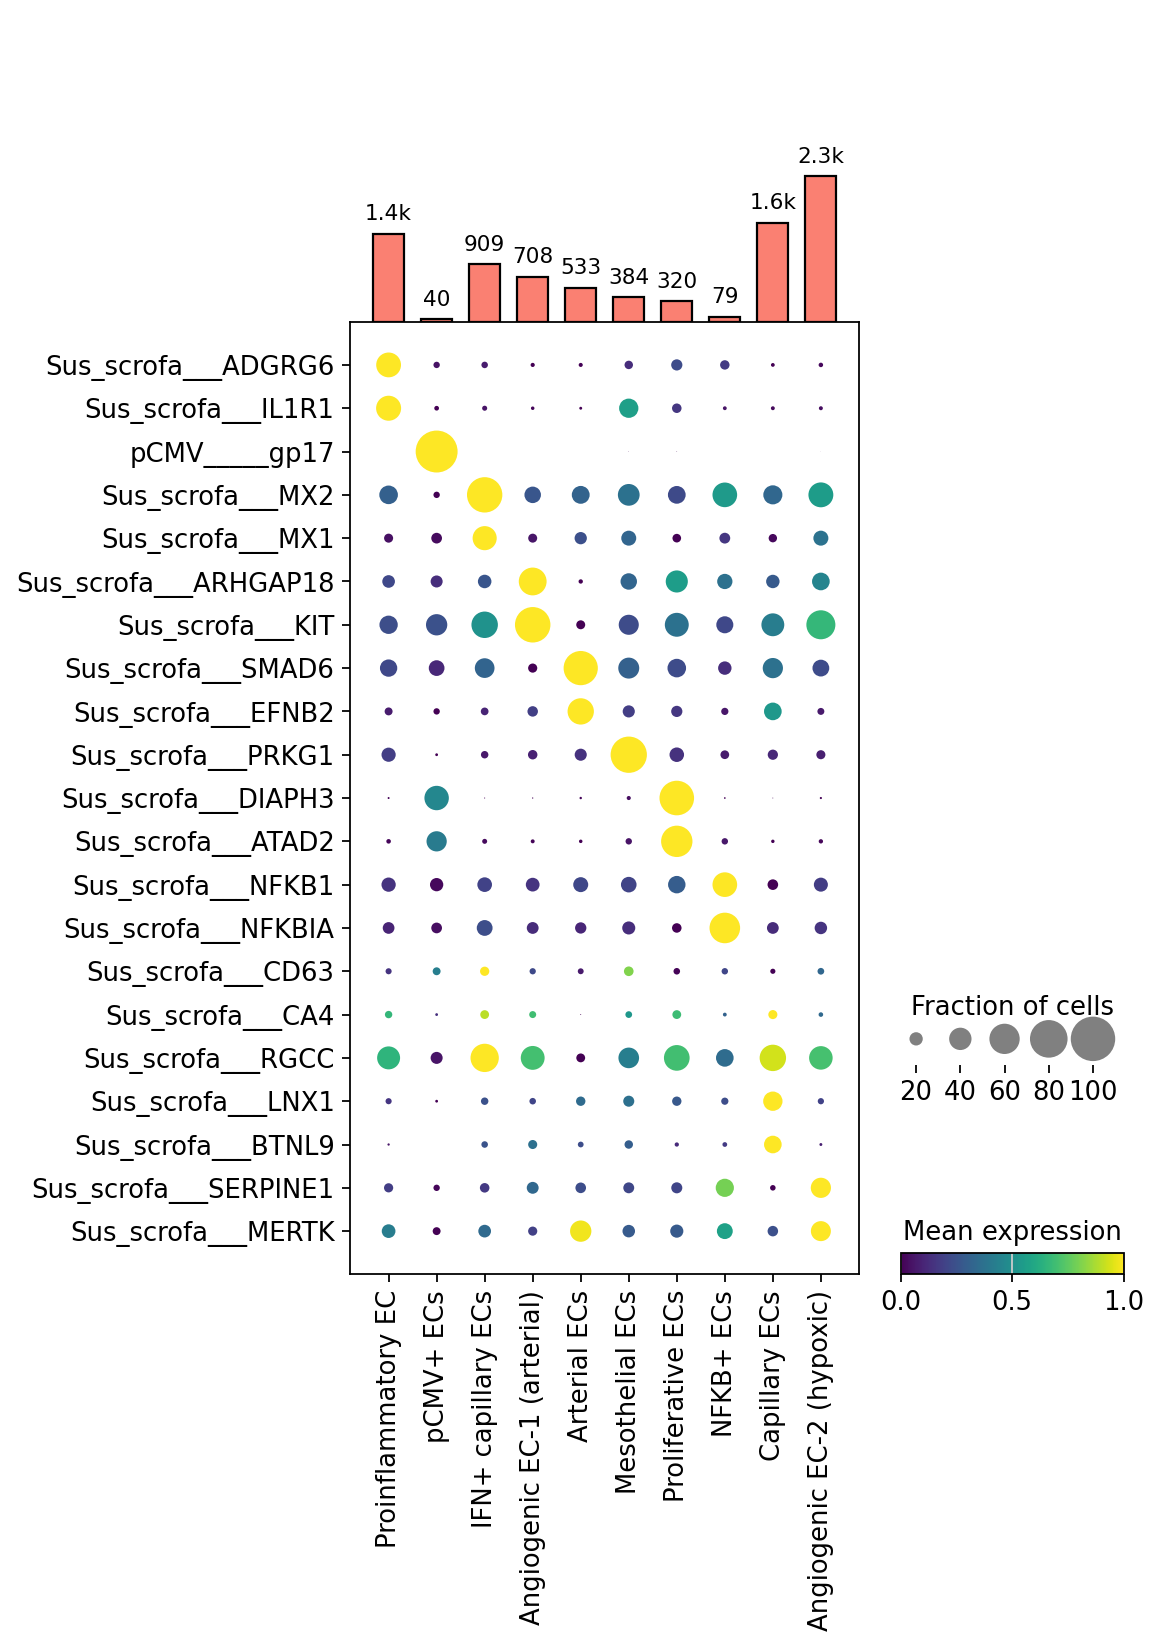

<Figure size 960x480 with 0 Axes>

In [77]:
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd

# Define marker genes for each cluster/cell type
two_marker_genes = {
    "Proinflammatory EC": ['Sus_scrofa___ADGRG6','Sus_scrofa___IL1R1'],
    "pCMV+ ECs": ['pCMV_____gp17'],
    "IFN+ capillary ECs": ['Sus_scrofa___MX2', 'Sus_scrofa___MX1'],
    "Angiogenic EC-1 (arterial)": ['Sus_scrofa___ARHGAP18', 'Sus_scrofa___KIT'],
    "Arterial ECs": ['Sus_scrofa___SMAD6', 'Sus_scrofa___EFNB2'],
    "Mesothelial ECs": ['Sus_scrofa___PRKG1'],
    "Proliferative ECs": ['Sus_scrofa___DIAPH3', 'Sus_scrofa___ATAD2'],
    "NFKB+ ECs": ['Sus_scrofa___NFKB1', 'Sus_scrofa___NFKBIA'],
    "Capillary ECs": ['Sus_scrofa___CD63', 'Sus_scrofa___CA4', 'Sus_scrofa___RGCC', 'Sus_scrofa___LNX1','Sus_scrofa___BTNL9'],
    "Angiogenic EC-2 (hypoxic)":['Sus_scrofa___SERPINE1','Sus_scrofa___MERTK']

}

# Extract the order of subtypes from the keys of the dictionary
ordered_subtypes = list(two_marker_genes.keys())

# Flatten the marker gene list for plotting
flat_marker_genes = [gene for genes in two_marker_genes.values() for gene in genes]

# Reorder the categories in the `EC_subtype_annotation` column
annotated_dea_adata.obs['EC_subtype_annotation'] = pd.Categorical(
    annotated_dea_adata.obs['EC_subtype_annotation'],
    categories=ordered_subtypes,
    ordered=True
)

# Create a DotPlot with reordered categories
sc.settings.set_figure_params(dpi=80, facecolor='white', figsize=[12, 6], fontsize=14)
dotplot = sc.pl.DotPlot(
    annotated_dea_adata, 
    flat_marker_genes, 
    groupby='EC_subtype_annotation',  # Replace with your appropriate groupby column
    standard_scale='var'
).add_totals(size=2)

dotplot.style(
    cmap="viridis", largest_dot=400, dot_edge_lw=0
).legend(
    width=2.5, colorbar_title='Mean expression', size_title='Fraction of cells'
).swap_axes().show()
# Save the updated plot
plt.savefig('/data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/results v2.1/Dotplot_top_markers.png', dpi=400, bbox_inches='tight')


In [4]:
annotated_dea_adata = sc.read ('/data2/core-med1/nhadizad/nastaran/Xenotransplant/v2.1 results & data/data v2.1/annotated_DEA_adata.h5ad')